# Jolien Bias analysis 2

In [1]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(ggplot2)
library(microshades)
library(openxlsx)
library(GenomicSEM)

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘gdata::nobs’ by ‘lavaan::nobs’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::first’ by ‘data.table::first’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::last’ by ‘data.table::last’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::resample’ by ‘R.utils::resample’ when loading ‘GenomicSEM’”
Warning message:
“replacing p

In [2]:
sample_sizes <- read_csv("
Path,N,Phenotype,Sample_Prevalence,Population_Prevalence
MDD,1118502.79,MDD,0.5,0.08
ADHD,128213.795,ADHD,0.5,0.05
ASD,44366.62,ASD,0.5,0.012
BIP,150669.892,BIP,0.5,0.02
SCZ,126281.975077309,SCZ,0.5,0.005
AGREE_Gupta.sumstats.gz:,235374,AGREE_Gupta,NA,NA
AGRI_Cheesman.sumstats.gz:,114687.803,AGRI_Cheesman,0.5,0.0327
ALC.sumstats.gz:,283162,ALC,NA,NA
ARTS_Cheesman.sumstats.gz:,194834.291,ARTS_Cheesman,0.5,0.0509
ASPEED_Linner.sumstats.gz:,404291,ASPEED_Linner,NA,NA
BMI.sumstats.gz:,283749,BMI,NA,NA
BP.sumstats.gz:,275793,BP,NA,NA
BUSI_Cheesman.sumstats.gz:,397458.518,BUSI_Cheesman,0.5,0.146
Cancer.sumstats.gz:,283034,Cancer,NA,NA
Coffee.sumstats.gz:,263464,Coffee,NA,NA
CONSC_Gupta.sumstats.gz:,234880,CONSC_Gupta,NA
DD_ANX.sumstats.gz:,282802,DD_ANX,0.11568243,0.1291
DEPRI_Neale.sumstats.gz:,336798,DEPRI_Neale,NA,NA
Diabetes.sumstats.gz:,283227,Diabetes,0.04837592,0.0502
DRINKS_Linner.sumstats.gz:,414343,DRINKS_Linner,NA,NA
EA_okbay.sumstats.gz:,765283,EA_okbay,NA,NA
EDU_Cheesman.sumstats.gz:,178741.31,EDU_Cheesman,0.5,0.0515
EDU.sumstats.gz:,283749,EDU,NA,NA
ENG_Cheesman.sumstats.gz:,586747.69,ENG_Cheesman,0.5,0.226
EXTRA_Gupta.sumstats.gz:,298772,EXTRA_Gupta,NA,NA
Fruit.sumstats.gz:,273875,Fruit,NA,NA
Health_Cheesman.sumstats.gz:,465932.983,Health_Cheesman,0.5,0.141
Height.sumstats.gz:,283749,Height,NA,NA
ICT_Cheesman.sumstats.gz:,124859.7,ICT_Cheesman,0.5,0.0268
ILL.sumstats.gz:,283743,ILL,NA,NA
INS.sumstats.gz:,283595,INS,NA,NA
LDL.sumstats.gz:,269545,LDL,NA,NA
LON.sumstats.gz:,279941,LON,0.18075697,0.2034
NatSci_Cheesman.sumstats.gz:,84600.915,NatSci_Cheesman,0.5,0.0186
NEURO_Gupta.sumstats.gz:,623482,NEURO_Gupta,NA,NA
NSEXP_Linner.sumstats.gz:,370711,NSEXP_Linner,NA,NA
OPEN_Gupta.sumstats.gz:,220015,OPEN_Gupta,NA,NA
PA.sumstats.gz:,271843,PA,NA,NA
REPERR_Schoeler.sumstats.gz:,62129,REPERR_Schoeler,NA,NA
Risk.sumstats.gz:,274537,Risk,0.26308983,0.2914
RT.sumstats.gz:,282217,RT,NA,NA
SERV_Cheesman.sumstats.gz:,205736.31,SERV_Cheesman,0.5,0.0949
Sex.sumstats.gz:,283749,Sex,0.54382694,0.4964
SMOKER_Linner.sumstats.gz:,518633,SMOKER_Linner,NA,NA
Smoking.sumstats.gz:,283749,Smoking,NA,NA
Social_Cheesman.sumstats.gz:,118436.525,Social_Cheesman,0.5,0.0337
UKBBpart.sumstats.gz:,283749,UKBBpart,NA,NA
VEG.sumstats.gz:,276203,VEG,NA,NA
wALC.sumstats.gz:,102020,wALC,NA,NA
wBMI.sumstats.gz:,102215,wBMI,NA,NA
wBP.sumstats.gz:,99220,wBP,NA,NA
wCancer.sumstats.gz:,101903,wCancer,NA,NA
wCoffee.sumstats.gz:,94643,wCoffee,NA,NA
wDD_ANX.sumstats.gz:,101859,wDD_ANX,0.1291,0.1291
wDiabetes.sumstats.gz:,102023,wDiabetes,0.0502,0.0502
wEDU.sumstats.gz:,102215,wEDU,NA,NA
wFruit.sumstats.gz:,98925,wFruit,NA,NA
wHeight.sumstats.gz:,102215,wHeight,NA,NA
wILL.sumstats.gz:,102213,wILL,NA,NA
wINS.sumstats.gz:,102156,wINS,NA,NA
wLDL.sumstats.gz:,97011,wLDL,NA,NA
wLON.sumstats.gz:,100928,wLON,0.2034,0.2034
wPA.sumstats.gz:,98035,wPA,NA,NA
wRisk.sumstats.gz:,99063,wRisk,0.2914,0.2914
wRT.sumstats.gz:,101556,wRT,NA,NA
wSex.sumstats.gz:,102215,wSex,0.4964,0.4964
wSmoking.sumstats.gz:,102215,wSmoking,NA,NA
wUKBBpart.sumstats.gz:,102215,wUKBBpart,NA,NA
wVEG.sumstats.gz:,100090,wVEG,NA,NA
"
)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 69 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Path, Phenotype
dbl (3): N, Sample_Prevalence, Population_Prevalence

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
#FROM the Cheesman code files as they fcking could not report them in the paper or the supplementary or the extra tables or wherever
#population.prev <- c(0.0515,0.0509	,0.0337	,0.146	,0.0186	,0.0268	,0.226	,0.0327	,0.141	,0.0949,
#NA)
#sample.prev   <- c(rep(0.5,10),NA)trait_names<-c("edu","arts","social","business","natural_sci","ict","engineering","agri","health","services""EA4")


In [4]:
sample_sizes <- mutate(sample_sizes, Neff = ifelse(is.na(Sample_Prevalence), N, 4*Sample_Prevalence*(1-Sample_Prevalence)*N))

In [5]:
sample_sizes <- select(sample_sizes, -c(Path, N))

In [6]:
sample_sizes <- select(sample_sizes, Phenotype, everything())

In [7]:
#sample prevalences can be set to 0.5 as N for the munged files has been converted to effective N. It could also be odne by specifying the correct sample prevalence when convertint to the liability scale, but for compatibility purposes the neffe variant has been applied
mental_prevalences <- c("MDD" = 0.08, "ADHD" = 0.05, "ASD" = 0.012, "BIP" = 0.02, "SCZ" = 0.005)
mental_names <- names(mental_prevalences)

other_prevalences <- c(
sample_sizes$Population_Prevalence[6:length(sample_sizes$Population_Prevalence)]
)
names(other_prevalences) <- sample_sizes$Phenotype[6:length(sample_sizes$Population_Prevalence)]
other_names <- names(other_prevalences)

all_prevalences <- c(mental_prevalences, other_prevalences)
all_names <- names(all_prevalences)

sample_prevalences <- sample_sizes$Sample_Prevalence
names(sample_prevalences) <- all_names

In [8]:
other_prevalences

AGREE_Gupta   AGRI_Cheesman             ALC   ARTS_Cheesman   ASPEED_Linner 
             NA          0.0327              NA          0.0509              NA 
            BMI              BP   BUSI_Cheesman          Cancer          Coffee 
             NA              NA          0.1460              NA              NA 
    CONSC_Gupta          DD_ANX     DEPRI_Neale        Diabetes   DRINKS_Linner 
             NA          0.1291              NA          0.0502              NA 
       EA_okbay    EDU_Cheesman             EDU    ENG_Cheesman     EXTRA_Gupta 
             NA          0.0515              NA          0.2260              NA 
          Fruit Health_Cheesman          Height    ICT_Cheesman             ILL 
             NA          0.1410              NA          0.0268              NA 
            INS             LDL             LON NatSci_Cheesman     NEURO_Gupta 
             NA              NA          0.2034          0.0186              NA 
   NSEXP_Linner      OPEN_Gupta              PA REPERR_Schoeler            Risk 
             NA              NA              NA              NA          0.2914 
             RT   SERV_Cheesman             Sex   SMOKER_Linner         Smoking 
             NA          0.0949          0.4964              NA              NA 
Social_Cheesman        UKBBpart             VEG            wALC            wBMI 
         0.0337              NA              NA              NA              NA 
            wBP         wCancer         wCoffee         wDD_ANX       wDiabetes 
             NA              NA              NA          0.1291          0.0502 
           wEDU          wFruit         wHeight            wILL            wINS 
             NA              NA              NA              NA              NA 
           wLDL            wLON             wPA           wRisk             wRT 
             NA          0.2034              NA          0.2914              NA 
           wSex        wSmoking       wUKBBpart            wVEG 
         0.4964              NA              NA              NA

In [9]:
#load the paths of necessary documents as not all of them are in this directory
ld <- "/local1/hdata/REF/eur_ref_ld_chr"
weights <- "/local1/hdata/REF/eur_w_ld_chr"
samples <- c("/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/adhd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/asd_munged.sumstats.gz",
             "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/bip_munged.sumstats.gz",
            "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/scz_munged.sumstats.gz")
other_basepath <- "/local1/scratch/pazweifel/sumstats_covariates/combined_munged_sumstats/" #phenotype.sumstats.gz

In [10]:
#create a matrices directory
dir.create("matrices_jolien_bias", showWarnings = FALSE)
#create a path for a covstruct object where you store the covariance structure of the bipolar disorders and store it in the matrices directory
covstruct_bip <- here::here("matrices_jolien_bias",paste("Mental", "R", sep = "."))
#extract population prevalence 
pop_prev <- as.vector(all_prevalences[mental_names])

samp_prev <- c(sample_prevalences[mental_names])
#check if the covstruct file already exists to not do the analysis unnecessarily, first time no file there
if (!file.exists(covstruct_bip)){
    covstruct_bip_ldsc <- ldsc(
        traits = samples,
        trait.names = mental_names,
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_bip_ldsc, covstruct_bip, control = c("all", "digits17"))
}

In [11]:
# do the same thing but include the other phenotypes one by one and name them after the current phenotype used
for (phenotype in other_names){
    covstruct_pheno <- here::here("matrices_jolien_bias",paste(phenotype,"R", sep = "."))
    #extract population prevalences
    pop_prev <- c(all_prevalences[mental_names], all_prevalences[phenotype])
    #fill the sample prevalences depending on pop vector
    samp_prev <- c(sample_prevalences[mental_names],sample_prevalences[phenotype])
    #concatenate the sample vector with the bip filepaths and the specific single phenotype filepath
    
    samples_plus1 <- c(samples, paste0(other_basepath,phenotype,".sumstats.gz"))
    
    #check if file already exists
    if (!file.exists(covstruct_pheno)){
        covstruct_ldsc <- ldsc(
            traits = samples_plus1,
            trait.names = c(mental_names, phenotype),
            sample.prev = samp_prev,
            population.prev = pop_prev,
            ld = ld,
            wld = weights,
            stand = TRUE
        )
        dput(covstruct_ldsc, covstruct_pheno, control = c("all", "digits17"))
    }
}
        

## Covariance

In [12]:
covstruct_base <- dget(here::here("matrices_jolien_bias/Mental.R"))

MDD,ADHD,ASD,BIP,SCZ
0.03792161,0.03365065,0.03651366,0.03196533,0.02668752
0.03365065,0.05301235,0.05447988,0.03449365,0.02807998
0.03651366,0.05447988,0.09825368,0.04425660,0.04183129
0.03196533,0.03449365,0.04425660,0.05180429,0.03647317
0.02668752,0.02807998,0.04183129,0.03647317,0.04601615


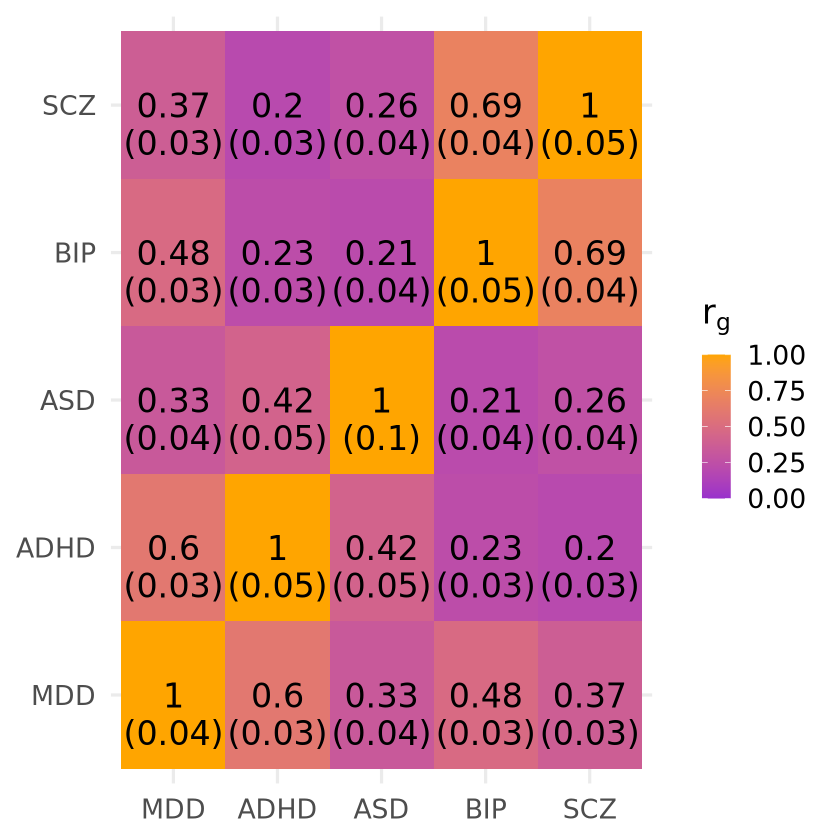

In [13]:
sstand <- covstruct_base$S_Stand
vstand <- covstruct_base$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:dim(vstand)[1]), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 2)
expanded_df$se <- round(error_vectorized, 2)
#create the ggplot
correlation_plot <- ggplot(expanded_df, aes(x = x, y = y, fill = values)) +
scale_fill_gradient(low = "darkorchid", high = "orange", limits = c(0, max(expanded_df$values))) +
theme_minimal(base_size = 20) +
geom_tile() +
theme(axis.title = element_blank()) +
labs(fill = expression(r[g])) +
geom_text(aes(label = values)) +
geom_text(aes(label = paste0("(",se,")"), vjust = 2))

correlation_plot

In [14]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/correlation_plot.pdf", correlation_plot, device = "pdf", width = 12, height = 10)

In [15]:
write_csv(expanded_df, file = "/local1/home/pazweifel/plots/jolien_extra_bias/correlations.csv")

## Modelling

In [16]:
#First define the base model
#get the base covariance matrix from the matrices directory
#define the model using NA*Clinical to say that this parameter loading has to be freely estimated, we fix the factor variance to 1 and ensure residual genetic variance of phenotypes isnt negative
base_model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

base.fit <- usermodel(covstruct_base,
                      estimation = "DWLS",
                      model = base_model,
                      imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.282 


In [17]:
#same thing but with fixed loading of 1 on the clinical, factor variance freely estimated
anchor_model <- "F1=~1*MDD+ASD+ADHD+BIP+SCZ
F1~~F1
"
anchor.fit <- usermodel(covstruct_base,
                        estimation = "DWLS",
                        model = anchor_model,
                        imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.22 


## Pathway models


In [18]:
#define the common and the independent pathway models and introduce a placeholder which can filled by the repsective phenotype corresponding to the used covariance matrix
#set the factor variance to 1
common.model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
F1~~{trait}
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

independent.model <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
MDD~~{trait}
ASD~~{trait}
ADHD~~{trait}
BIP~~{trait}
SCZ~~{trait}
F1~~1*F1
MDD~~a*MDD
a > 0.0001
"

In [19]:
#define a list with trait names named after themselves, so that that the naming remains when using this list with lapply and therefore specific elements can be accessed by name
traits <- other_names
names(traits) <- traits
traits

AGREE_Gupta     AGRI_Cheesman               ALC     ARTS_Cheesman 
    "AGREE_Gupta"   "AGRI_Cheesman"             "ALC"   "ARTS_Cheesman" 
    ASPEED_Linner               BMI                BP     BUSI_Cheesman 
  "ASPEED_Linner"             "BMI"              "BP"   "BUSI_Cheesman" 
           Cancer            Coffee       CONSC_Gupta            DD_ANX 
         "Cancer"          "Coffee"     "CONSC_Gupta"          "DD_ANX" 
      DEPRI_Neale          Diabetes     DRINKS_Linner          EA_okbay 
    "DEPRI_Neale"        "Diabetes"   "DRINKS_Linner"        "EA_okbay" 
     EDU_Cheesman               EDU      ENG_Cheesman       EXTRA_Gupta 
   "EDU_Cheesman"             "EDU"    "ENG_Cheesman"     "EXTRA_Gupta" 
            Fruit   Health_Cheesman            Height      ICT_Cheesman 
          "Fruit" "Health_Cheesman"          "Height"    "ICT_Cheesman" 
              ILL               INS               LDL               LON 
            "ILL"             "INS"             "LDL"             "LON" 
  NatSci_Cheesman       NEURO_Gupta      NSEXP_Linner        OPEN_Gupta 
"NatSci_Cheesman"     "NEURO_Gupta"    "NSEXP_Linner"      "OPEN_Gupta" 
               PA   REPERR_Schoeler              Risk                RT 
             "PA" "REPERR_Schoeler"            "Risk"              "RT" 
    SERV_Cheesman               Sex     SMOKER_Linner           Smoking 
  "SERV_Cheesman"             "Sex"   "SMOKER_Linner"         "Smoking" 
  Social_Cheesman          UKBBpart               VEG              wALC 
"Social_Cheesman"        "UKBBpart"             "VEG"            "wALC" 
             wBMI               wBP           wCancer           wCoffee 
           "wBMI"             "wBP"         "wCancer"         "wCoffee" 
          wDD_ANX         wDiabetes              wEDU            wFruit 
        "wDD_ANX"       "wDiabetes"            "wEDU"          "wFruit" 
          wHeight              wILL              wINS              wLDL 
        "wHeight"            "wILL"            "wINS"            "wLDL" 
             wLON               wPA             wRisk               wRT 
           "wLON"             "wPA"           "wRisk"             "wRT" 
             wSex          wSmoking         wUKBBpart              wVEG 
           "wSex"        "wSmoking"       "wUKBBpart"            "wVEG"

In [20]:
#make a named vector with all the common models and all the applied models, take advantage of the palceholder introduced
traits_common.models <- lapply(traits, 
                               function(trait) str_glue(common.model)
)

traits_independent.models <- lapply(traits,
                                    function(trait) str_glue(independent.model)
)

In [21]:
#load the genetic covariance matrices
trait.covstructs <- lapply(traits, 
                           function(trait) dget(here::here("matrices_jolien_bias",paste(trait,"R", sep = ".")))
)

In [22]:
#now fit the common and the independent models using the two vectors
trait_common.fit <- lapply(traits, 
                           function(trait) {
                               usermodel(trait.covstructs[[trait]],
                               estimation = "DWLS",
                               model = traits_common.models[[trait]],
                               imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.255 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.278 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.244 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.285 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.253 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.263 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.247 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[

In [23]:
trait_independent.fit <- lapply(traits,
                                function(trait) {
                                    usermodel(
                                        trait.covstructs[[trait]],
                                        estimation = "DWLS",
                                        model = traits_independent.models[[trait]],
                                        imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.288 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.297 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.481 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.287 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.258 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.229 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.243 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[

Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.258 


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.255 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.251 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.258 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.278 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.244 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.259 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.279 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[

...

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.243 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.246 


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.249 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.235 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.244 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.238 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.237 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.276 


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_independent.models[[trait]], :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.275 


In [24]:
base.fit

$modelfit
      chisq df     p_chisq      AIC       CFI      SRMR
df 346.9194  5 8.05993e-73 366.9194 0.8086941 0.1161236

$results
    lhs op  rhs Unstand_Est          Unstand_SE STD_Genotype    STD_Genotype_SE
7    F1 =~  MDD  0.15257127 0.00578414308510533    0.7536164 0.0285704335261121
5    F1 =~  ASD  0.14152893  0.0137127551142982    0.4415231 0.0427792082124253
4    F1 =~ ADHD  0.18809048  0.0125784670418695    0.5245599 0.0350797078345678
6    F1 =~  BIP  0.23889582 0.00992279769211429    0.7011881 0.0291245660719664
8    F1 =~  SCZ  0.24231852  0.0121650111277629    0.5852011  0.029378599249413
10  MDD ~~  MDD  0.01770882 0.00188458092380272    0.4320623 0.0459801447196026
1  ADHD ~~ ADHD  0.09319307 0.00625104913070096    0.7248379 0.0486193828570966
2   ASD ~~  ASD  0.08271996  0.0100332324461191    0.8050572 0.0976465322748418
3   BIP ~~  BIP  0.05900660 0.00505676589487598    0.5083350 0.0435635926493514
11  SCZ ~~  SCZ  0.11274167 0.00675716216335292    0.6575385 0.0394095426853451
9    F1 ~~   F1  1.00000000                        1.0000000                   
     STD_All       p_value
7  0.7536164 2.482706e-153
5  0.4415231  5.664797e-25
4  0.5245597  1.480606e-50
6  0.7011882 4.520175e-128
8  0.5852014  2.768271e-88
10 0.4320623  5.630854e-21
1  0.7248371  2.906831e-50
2  0.8050573  1.657172e-16
3  0.5083351  1.839104e-31
11 0.6575393  1.691689e-62
9  1.0000000            NA

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
            MDD       ADHD        ASD        BIP        SCZ
MDD  0.04098681 0.02869720 0.02159325 0.03644864 0.03697085
ADHD 0.02869720 0.12857110 0.02662025 0.04493403 0.04557781
ASD  0.02159325 0.02662025 0.10275040 0.03381067 0.03429508
BIP  0.03644864 0.04493403 0.03381067 0.11607781 0.05788888
SCZ  0.03697085 0.04557781 0.03429508 0.05788888 0.17145993

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
               MDD          ADHD           ASD           BIP           SCZ
MDD  -2.311385e-08  1.457309e-02  8.535360e-05 -3.604893e-03 -5.873364e-03
ADHD  1.457309e-02  4.680337e-08  2.207756e-02 -1.686704e-02 -1.616638e-02
ASD   8.535360e-05  2.207756e-02  1.395602e-07 -1.084044e-02  3.350906e-04
BIP  -3.604893e-03 -1.686704e-02 -1.084044e-02  6.122899e-08  3.905936e-02
SCZ  -5.873364e-03 -1.616638e-02  3.350906e-04  3.905936e-02  7.396512e-08

In [25]:
base.results.table <- mutate(tibble(base.fit$results), Model = "Base", External_phenotype = "None", p_value = as.character(p_value)) %>% relocate(Model, External_phenotype)

base.modelfit.table <- mutate(tibble(base.fit$modelfit), Model = "Base", External_phenotype = "None") %>% relocate(Model, External_phenotype)

In [26]:
trait_common.results.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- trait_common.fit[[trait]]$results
        mutate(tibble(temp), Model = "Common", External_phenotype = trait, p_value = as.character(temp$p_value)) %>% relocate(Model, External_phenotype)
        }))

trait_common.modelfit.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- trait_common.fit[[trait]]$modelfit
        mutate(tibble(temp), Model = "Common", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        }))

In [27]:
combined.table.results <- bind_rows(base.results.table, trait_common.results.table)
combined.table.modelfit <- bind_rows(base.modelfit.table, trait_common.modelfit.table)

In [28]:
write_csv(combined.table.results, file = "/local1/home/pazweifel/plots/jolien_extra_bias/combined.results.table.csv")
write_csv(combined.table.modelfit, file = "/local1/home/pazweifel/plots/jolien_extra_bias/combined.modelfit.table.csv")

## Heritability

In [29]:
#extract the heritabilities and their se
#for the base phenotypes
temp <- covstruct_base
S <- temp$S
V <- temp$V

base_traits_n <- length(dimnames(S)[[2]])
max_index_se <- dim(V)[1]

herit_base <- sapply(c(1:base_traits_n), function(index) S[index,index])
                  
increments <- seq(base_traits_n, 1, by = -1)

index_se <- c(1, 1 + cumsum(increments))
index_se <- index_se[index_se <= max_index_se]

se_base <- sapply(index_se, function(index) sqrt(V[index, index]))
           
names <- dimnames(S)[[2]]
                
base_heritabilities <- tibble(trait = names, heritability = herit_base, se = se_base, group = "internal")

In [30]:
ext_heritabilities <- bind_rows(
                            lapply(traits, function(trait) {
                                temp <- trait.covstructs[[trait]]
                                heritability <- temp$S[base_traits_n+1,base_traits_n+1]
                                se <- sqrt(temp$V[dim(temp$V)[1],dim(temp$V)[1]])
                                tibble(heritability = heritability, se = se, group = "external")
                                }),
                                .id = "trait")
                                

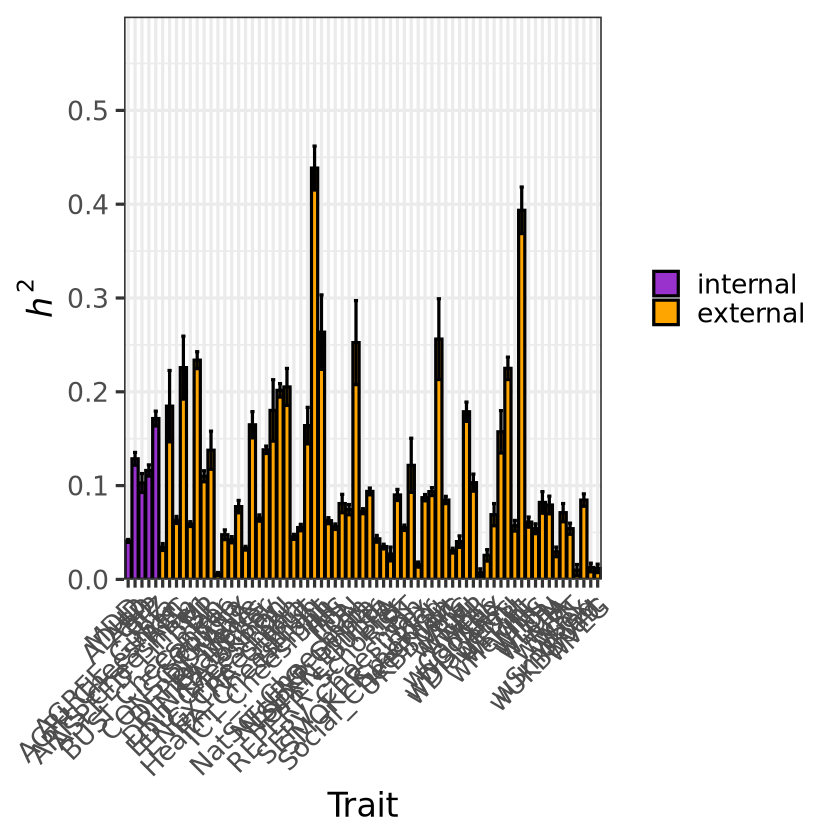

In [31]:
all_heritabilities <- bind_rows(base_heritabilities, ext_heritabilities)
all_heritabilities$trait <- factor(all_heritabilities$trait, levels = unique(all_heritabilities$trait))
all_heritabilities$group <- factor(all_heritabilities$group, levels = c("internal", "external"))

heritabilities_jolien_paper <- ggplot(all_heritabilities, aes(x = trait, y = heritability, fill = group)) + 
geom_col(color = "black") +
theme_bw(base_size = 20) +
geom_errorbar(aes(ymin = heritability - se, ymax = heritability + se), width = 0.6) +
theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.title = element_blank()) +
labs(x = "Trait", y = expression(italic(h^2))) +
scale_y_continuous(limits = c(0, 0.6), expand = c(0,0)) +
scale_fill_manual(values = c("darkorchid", "orange"))

heritabilities_jolien_paper

In [32]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/heritabilities_all.pdf", heritabilities_jolien_paper, device = "pdf", width = 22, height = 10)

In [33]:
write_csv(all_heritabilities, file = "/local1/home/pazweifel/plots/jolien_extra_bias/heritabilities.csv")

## ChiSquared difference between common and independent model

In [34]:
#define the chisquared function: a smaller chi squared value means that the estimated models covariance structure fits the observed covariance structure well
#if you subtract the chi squared of the independent model from the common one, you can see how much better it is
#the difference follows a chisquared distribution and you can calculate the p value of this observation

model_diff_chisq <- function(common_model, independent_model) {
    q_chisq <- common_model$modelfit$chisq - independent_model$modelfit$chisq
    q_df <- common_model$modelfit$df - independent_model$modelfit$df
    q_p <- pchisq(q = q_chisq, df = q_df, lower.tail =FALSE)
    data.frame(q_chisq, q_df, q_p)
}

model_diffs <- bind_rows(
    lapply(traits, function(trait) {
        model_diff_chisq(trait_common.fit[[trait]], trait_independent.fit[[trait]])
        }
    ),
    .id = "Trait"
    ) %>% 
    mutate(FDR = p.adjust(q_p, method = "fdr"))

In [35]:
#merge with samplesize df first
model_diff_neff_df <- left_join(model_diffs, sample_sizes, by = c("Trait" = "Phenotype"))
model_diff_neff_df$Significant <- ifelse(model_diff_neff_df$FDR < 0.05, "FDR < 0.05", "No")

In [36]:
require(ggrepel)
model_diff_neff_df

Loading required package: ggrepel



Trait,q_chisq,q_df,q_p,FDR,Sample_Prevalence,Population_Prevalence,Neff,Significant
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AGREE_Gupta,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.00,FDR < 0.05
AGRI_Cheesman,38.177299,4,1.030044e-07,1.997660e-07,0.50000000,0.0327,114687.80,FDR < 0.05
ALC,-7.366641,4,1.000000e+00,1.000000e+00,NA,NA,283162.00,No
ARTS_Cheesman,13.084177,4,1.087173e-02,1.449564e-02,0.50000000,0.0509,194834.29,FDR < 0.05
ASPEED_Linner,203.970805,4,5.261120e-43,2.104448e-42,NA,NA,404291.00,FDR < 0.05
BMI,472.255877,4,6.697642e-101,8.572982e-100,NA,NA,283749.00,FDR < 0.05
BP,-5.394028,4,1.000000e+00,1.000000e+00,NA,NA,275793.00,No
BUSI_Cheesman,18.256854,4,1.099301e-03,1.675125e-03,0.50000000,0.1460,397458.52,FDR < 0.05
Cancer,14.320820,4,6.338486e-03,8.818763e-03,NA,NA,283034.00,FDR < 0.05


Warning message:
“ggrepel: 44 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


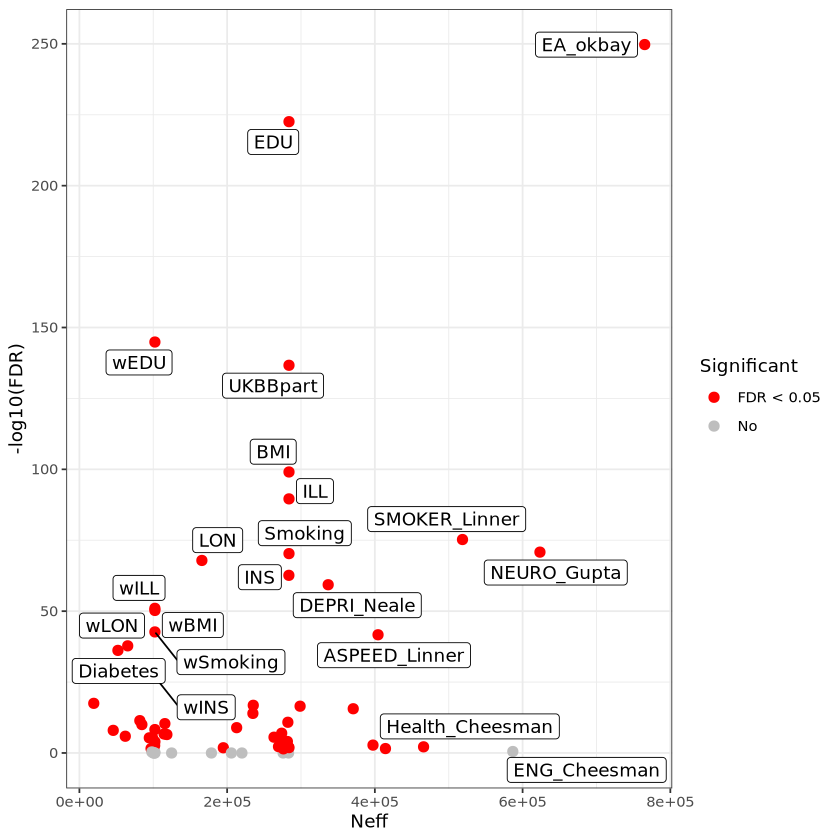

In [37]:
#create a dotplot with -log10(p) on the y axis and neff on the x axis

chisq_diff_plot <- ggplot(model_diff_neff_df, aes(x = Neff, y = -log10(FDR), label = Trait)) +
geom_point(aes(color = Significant), size = 2.5) +
scale_color_manual(values = c("red","grey")) +
theme_bw() +
geom_label_repel()

chisq_diff_plot

In [38]:
ggsave("../plots/jolien_extra_bias/chisq_diff_bipolar.svg", chisq_diff_plot, width = 10, height = 10, create.dir = TRUE)

Warning message:
“ggrepel: 36 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [39]:
semPlotModel_GSEM <- function(gsem.object=cfa_bipolar){ 
        object <- gsem.object$results
        object$free=0
        numb=1:length(which(object$op!="~~"))
        object$free[which(object$op!="~~")]=numb
        varNames <- lavaanNames(object, type = "ov")
        factNames <- lavaanNames(object, type = "lv")
        factNames <- factNames[!factNames %in% varNames]
        n <- length(varNames)
        k <- length(factNames)
        if (is.null(object$label)) 
          object$label <- rep("", nrow(object))
        semModel <- new("semPlotModel")
        object$std <- object[,"STD_Genotype"]
        object$est <- object[,"Unstand_Est"]
        if (is.null(object$group)) 
          object$group <- ""
        semModel@Pars <- data.frame(label = object$label, lhs = ifelse(object$op == "~" | object$op == "~1", object$rhs, object$lhs), edge = "--", 
                                    rhs = ifelse(object$op == "~" | object$op == "~1", object$lhs, object$rhs), est = object$est, std = object$std, std = NA, group = object$group, 
                                    fixed = object$free==0, par = object$free, stringsAsFactors = FALSE)
        semModel@Pars$edge[object$op == "~~"] <- "<->"
        semModel@Pars$edge[object$op == "~*~"] <- "<->"
        semModel@Pars$edge[object$op == "~"] <- "~>"
        semModel@Pars$edge[object$op == "=~"] <- "->"
        semModel@Pars$edge[object$op == "~1"] <- "int"
        semModel@Pars$edge[grepl("\\|", object$op)] <- "|"
        semModel@Thresholds <- semModel@Pars[grepl("\\|", semModel@Pars$edge), 
                                             -(3:4)]
        semModel@Pars <- semModel@Pars[!object$op %in% c(":=", "<", 
                                                         ">", "==", "|", "<", ">"), ]
        semModel@Vars <- data.frame(name = c(varNames, factNames), 
                                    manifest = c(varNames, factNames) %in% varNames, exogenous = NA, 
                                    stringsAsFactors = FALSE)
        semModel@ObsCovs <- list()
        semModel@ImpCovs <- list()
        semModel@Computed <- FALSE
        semModel@Original <- list(object)
        return(semModel)
 }

In [40]:
library(lavaanPlot)
library(lavaan)
library(semPlot)

This is lavaan 0.6-20
lavaan is FREE software! Please report any bugs.



In [41]:
for (trait in other_names){
    #define the two sem objects
    current_fit_common <- semPlotModel_GSEM(gsem.object = trait_common.fit[[trait]])
    current_fit_independent <- semPlotModel_GSEM(gsem.object = trait_independent.fit[[trait]])
    #extract the std estimate and the corresponding se to plot them both, for common and independent model
    se <- trait_common.fit[[trait]]$results$STD_Genotype_SE
    est <- trait_common.fit[[trait]]$results$STD_Genotype
    est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

    se_in <- trait_independent.fit[[trait]]$results$STD_Genotype_SE
    est_in <- trait_independent.fit[[trait]]$results$STD_Genotype
    est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")
    #save the common model as an svg object, remove the last label as overlapping and known as factor artificially set to variance of 1
    svg(paste0("/local1/home/pazweifel/plots/jolien_extra_bias/",trait,"_common_model.svg"), width = 11, height = 12)
    semPaths(current_fit_common, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        esize = 2,
        edgeLabels = est.se[1:12])
    dev.off()
    #save the indpendent mode as an svg object
    svg(paste0("/local1/home/pazweifel/plots/jolien_extra_bias/",trait,"_independent_model.svg"), width = 12, height = 11)
    semPaths(current_fit_independent, whatLabels = "std", layout = "circle2", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        rotation = 1,
        esize = 2,
        edge.label.position = 0.45,
        edgeLabels = est.se_in)
    dev.off()
}

## GSEM Qtrait function to calculate 

In [42]:
trait.qtrait <- bind_rows(lapply(traits, function(trait) {
    QTrait(
    LDSCoutput = trait.covstructs[[trait]],
    indicators = mental_names,
    traits = trait)
    }),
    .id = "Trait")


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


corrplot 0.95 loaded




 ---------------------------- 

 Fitting common pathways model for external trait AGREE_Gupta 
 

 Fitting independent pathways model for external trait AGREE_Gupta 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait AGRI_Cheesman 
 

 Fitting independent pathways model for external trait AGRI_Cheesman 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ALC 
 

 Fitting independent pathways model for external trait ALC 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ARTS_Cheesman 
 

 Fitting independent pathways model for external trait ARTS_Cheesman 
 

 Fitting follow-up model for external trait ARTS_Cheesman 
 

 Most egregious outlier: ASD 
 

 ---------------------------- 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait AS

## Visualization of Correlations for different models

In [43]:
#first extract the model implied covariances from the common model fit and convert to correlations
target_common_rg <- bind_rows(
    lapply(trait_common.fit, function(fit) {
        cov2cor(V = fit$resid_cov$'Model Implied Covariance Matrix')[1:5, 6]
        }
    ),
    .id = "trait")
    

In [44]:
#add the common pathway label and make the df longer so that you have one correlation per line to plot afterwards
target_common_rg <- target_common_rg %>% mutate(Pathway = "Common") %>% pivot_longer(MDD:SCZ, names_to = "Mental", values_to = "rg")

In [45]:
#now extract correlation of external phenotype with common factor form results table (F1~~E)
target_common_factor_rg <- bind_rows(
    lapply(trait_common.fit, function(fit){
        fit$results %>%
        filter(
            lhs == "F1",
            rhs != "F1",
            !rhs %in% mental_names
            ) %>%
        transmute(Mental = "F1", rg = STD_Genotype, se = as.numeric(STD_Genotype_SE)
                  )
        }
    ),
    .id = "trait"
    ) %>%
    mutate(Pathway = "Common")

In [46]:
#now the same for the independent model, extract from model-implied covariance matrix
target_independent_rg <- bind_rows(
    lapply(
        trait_independent.fit, function(fit){
            cov2cor(fit$resid_cov$'Model Implied Covariance Matrix')[1:5, 6]
            }),
    .id = "trait"
    ) %>% mutate(Pathway = "Independent") %>% pivot_longer(MDD:SCZ, names_to = "Mental", values_to = "rg")

In [47]:
#for the independent model extract the correlation between factor and external trait form results
target_independent_rg_se <- bind_rows(
    lapply(trait_independent.fit, function(fit){
        fit$results %>% filter(
            lhs %in% mental_names,
            lhs != rhs
            ) %>% transmute(
            Mental = lhs, rg = STD_Genotype, se = as.numeric(STD_Genotype_SE))
        }),
        .id = "trait"
    ) %>% mutate(
    Pathway = "Independent")
        

In [48]:

target_sample_sizes <-
  bind_rows(
    lapply(trait.covstructs, function(covs) {
      # get sample sizes
      N <- covs$N
      # create a matrix the same size as the cov matrix
      Nmat <- covs$S
      # fill in lower triangle
      Nmat[TRUE] <- NA
      Nmat[lower.tri(Nmat, diag = TRUE)] <- N
      # extract sample size and names from matrix
      Ns <- Nmat[6, 1:5]
      N_names <- dimnames(Nmat)[[2]][1:5]
      # add total N for factor
      N_total <- sum(Ns)
      tibble(N = c(Ns, N_total), Mental = c(N_names, "F1"))
    }),
    .id = "trait"
  )

In [49]:
target_rg <- bind_rows(
    target_common_rg, 
    target_common_factor_rg, 
    target_independent_rg_se) %>% left_join(
    target_sample_sizes,
    by = c("trait", "Mental")) %>% left_join(
    model_diff_neff_df, by = c("trait" = "Trait"))

In [50]:
target_rg |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg))

trait,Pathway,Mental,rg,se,N,q_chisq,q_df,q_p,FDR,Sample_Prevalence,Population_Prevalence,Neff,Significant
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AGREE_Gupta,Independent,MDD,-0.366826288,0.03222734,508468.22,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.0,FDR < 0.05
AGREE_Gupta,Independent,ASD,-0.291130111,0.08626209,102190.21,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.0,FDR < 0.05
AGREE_Gupta,Independent,ADHD,-0.274194528,0.04939985,173191.35,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.0,FDR < 0.05
AGREE_Gupta,Independent,BIP,-0.124461849,0.04882440,182665.55,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.0,FDR < 0.05
AGREE_Gupta,Independent,SCZ,-0.176071963,0.04002284,172195.86,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.0,FDR < 0.05
AGRI_Cheesman,Independent,MDD,-0.354535152,0.06006618,103508.42,38.177299,4,1.030044e-07,1.997660e-07,0.5,0.0327,114687.8,FDR < 0.05
AGRI_Cheesman,Independent,ASD,-0.104580046,0.11029544,20762.19,38.177299,4,1.030044e-07,1.997660e-07,0.5,0.0327,114687.8,FDR < 0.05
AGRI_Cheesman,Independent,ADHD,-0.258127603,0.06737014,35206.19,38.177299,4,1.030044e-07,1.997660e-07,0.5,0.0327,114687.8,FDR < 0.05
AGRI_Cheesman,Independent,BIP,-0.189613039,0.06393156,37197.35,38.177299,4,1.030044e-07,1.997660e-07,0.5,0.0327,114687.8,FDR < 0.05


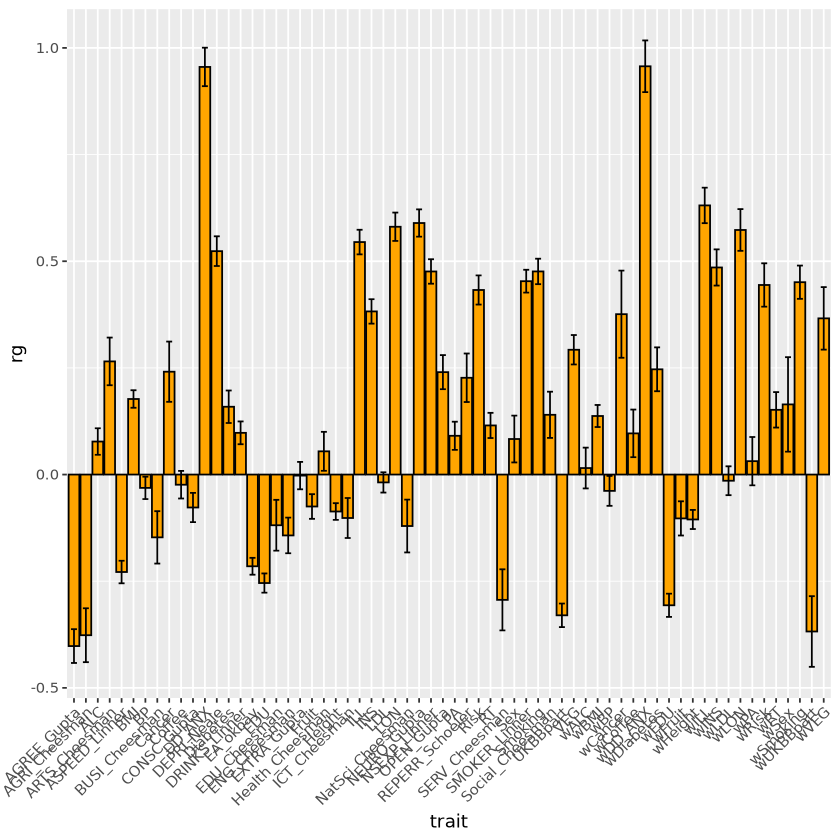

In [51]:
correlation_plot_common <- ggplot(filter(target_rg, Mental == "F1"), aes(x = trait, y = rg)) +
geom_col(color = "black", fill = "orange") +
geom_errorbar(aes(ymin = rg - se, ymax = rg + se), width = 0.5) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

correlation_plot_common

In [52]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/common_factor_correlation_all.svg", correlation_plot_common, device = svg, width = 20)

Saving 20 x 6.67 in image


Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale r

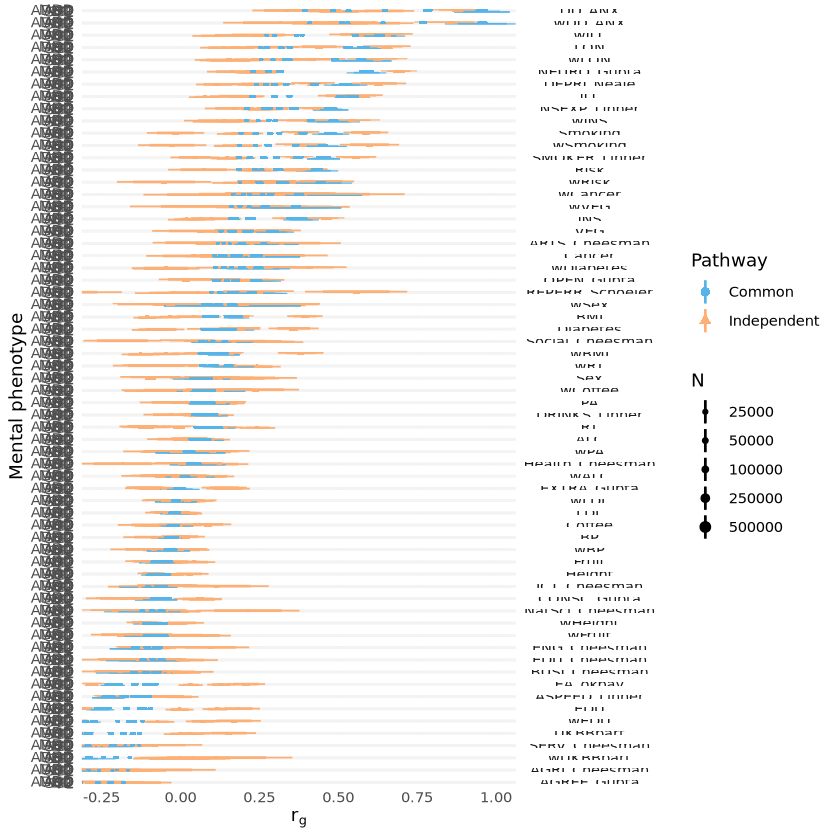

In [53]:
correlation_plot <- ggplot(
  target_rg |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)),
  aes(
    x = Mental, y = rg,
    ymin = rg + se * qnorm(0.025), ymax = rg + se * qnorm(0.975),
    shape = Pathway, colour = Pathway, size = N
  )
) +
  geom_linerange(aes(ymin = rg + se * qnorm(0.1), ymax = rg + se * qnorm(0.9)), linewidth = 0.75) +
  geom_pointrange() +
  facet_grid(rows = vars(trait)) +
  scale_x_discrete("Mental phenotype", limits = c("F1", rev(mental_names))) +
  scale_y_continuous(expression(r[g]), breaks = c(-0.25, 0, 0.25, 0.5, 0.75, 1)) +
  scale_size_area(breaks = c(2.5e4, 5e4, 1e5, 2.5e5, 5e5), max_size = 1) +
  scale_colour_discrete(
    type = c(
      microshades_cvd_palettes$micro_cvd_blue[4],
      microshades_cvd_palettes$micro_cvd_orange[2]
    )
  ) +
  coord_flip(ylim = c(-0.25, 1)) +
  theme_minimal() +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_line(linewidth = 0.1)) +
  theme(strip.text.y.right = element_text(angle = 0))

correlation_plot

In [54]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/Correlation_comparison.svg", plot = correlation_plot, width = 12, height = 50, device = "svg", limitsize = FALSE)

Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale r

In [55]:
target_rg |>
    pivot_wider(names_from = c("Pathway"), values_from = c("rg", "se")) |>
    mutate(rgD = rg_Independent - rg_Common) |>
    select(-se_Common) |>
    arrange(desc(abs(rgD))) |>
    filter(abs(rgD) > se_Independent) |> select(-c(Neff, Significant))


trait,Mental,N,q_chisq,q_df,q_p,FDR,Sample_Prevalence,Population_Prevalence,rg_Common,rg_Independent,se_Independent,rgD
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
wUKBBpart,ADHD,114017.79,45.89110,4,2.594777e-09,5.535524e-09,NA,NA,-0.20430200,-0.75266965,0.10446295,-0.5483676
REPERR_Schoeler,ASD,52502.17,34.18929,4,6.814602e-07,1.246099e-06,NA,NA,0.09827034,-0.40740583,0.11292488,-0.5056762
REPERR_Schoeler,ADHD,88894.11,34.18929,4,6.814602e-07,1.246099e-06,NA,NA,0.12356753,0.55675260,0.08272890,0.4331851
UKBBpart,ADHD,189968.88,646.54186,4,1.306550e-138,2.090480e-137,NA,NA,-0.22076920,-0.63417605,0.03714575,-0.4134068
EDU,ADHD,189968.88,1044.37907,4,8.602515e-225,2.752805e-223,NA,NA,-0.17128677,-0.58440641,0.03209269,-0.4131196
wEDU,ADHD,114017.79,684.98049,4,6.227172e-147,1.328463e-145,NA,NA,-0.19932036,-0.60301166,0.03816080,-0.4036913
EA_okbay,ADHD,311962.67,1171.19481,4,2.796530e-252,1.789780e-250,NA,NA,-0.14487259,-0.52228162,0.02805122,-0.3774090
wSmoking,ADHD,114017.79,208.75197,4,4.929768e-44,2.103368e-43,NA,NA,0.27442648,0.59910277,0.04793937,0.3246763
wBMI,ADHD,114017.79,244.06154,4,1.238008e-51,5.659466e-51,NA,NA,0.07899427,0.38099130,0.03691981,0.3019970


## Follow-up models: Adding direct paths from external phenotype to internal traits depending on Qtrait results

In [56]:
follow_up_model_core <- "F1=~NA*MDD+ASD+ADHD+BIP+SCZ
F1~~1*F1
MDD~~a*MDD
a > 0.0001
F1~~{trait}
"
internal_1_model <- "\n{internal1} ~ b*{trait}"
internal_2_model <- "\n{internal2} ~ c*{trait}"
internal_3_model <- "\n{internal3} ~ d*{trait}"
internal_4_model <- "\n{internal4} ~ e*{trait}"

internal_models <- c(internal_1_model, internal_2_model, internal_3_model, internal_4_model)

In [57]:
#extracting the relevant traits
follow_up_names <- trait.qtrait[trait.qtrait$Unconstrained_paths != "None",]$Trait
traits[follow_up_names]
follow_up_table <- trait.qtrait[trait.qtrait$Unconstrained_paths != "None",]

ARTS_Cheesman               BMI       CONSC_Gupta       DEPRI_Neale 
  "ARTS_Cheesman"             "BMI"     "CONSC_Gupta"     "DEPRI_Neale" 
         Diabetes          EA_okbay               EDU               ILL 
       "Diabetes"        "EA_okbay"             "EDU"             "ILL" 
              INS               LON       NEURO_Gupta   REPERR_Schoeler 
            "INS"             "LON"     "NEURO_Gupta" "REPERR_Schoeler" 
             Risk                RT     SMOKER_Linner           Smoking 
           "Risk"              "RT"   "SMOKER_Linner"         "Smoking" 
  Social_Cheesman          UKBBpart              wBMI           wCancer 
"Social_Cheesman"        "UKBBpart"            "wBMI"         "wCancer" 
        wDiabetes              wEDU              wINS              wLON 
      "wDiabetes"            "wEDU"            "wINS"            "wLON" 
            wRisk               wRT          wSmoking         wUKBBpart 
          "wRisk"             "wRT"        "wSmoking"       "wUKBBpart"

In [58]:
their_follow_up_models.fit <- lapply(traits[follow_up_names], function(trait) {
                                outliers <- str_split_1(follow_up_table[follow_up_table$Trait == trait,][1,]$Unconstrained_paths, pattern = ",")
                                #assign outliers to the variables
                                internal1 <- outliers[1]
                                internal2 <- outliers[2]
                                internal3 <- outliers[3]
                                internal4 <- outliers[4]

                                combined_model <- follow_up_model_core
                                for (i in 1:length(outliers)){
                                    combined_model <- paste0(combined_model,internal_models[i])
                                    
                                }
                                #fit the follow up model with the pasted construct
                                usermodel(covstruc = trait.covstructs[[trait]],
                                          estimation = "DWLS",
                                          model = str_glue(combined_model),
                                          imp_cov = TRUE
    )     
})



[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.386 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.297 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.32 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.464 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.303 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.32 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.307 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[

Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.317 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.337 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.373 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.408 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.375 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.371 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.314 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[

Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.331 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.355 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.731 
[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.406 


In [59]:
for (trait in follow_up_names){
    #currentmodel
    temp <- their_follow_up_models.fit[[trait]]
    #create the semmodel used in the semPaths function
    tempsem <- semPlotModel_GSEM(temp)
    #extract the standardized estimates and the errors from results
    est_temp <- temp$results$STD_Genotype
    se_temp <- temp$results$STD_Genotype_SE

    labels_temp <- paste(round(as.numeric(est_temp), 2),"\n (", round(as.numeric(se_temp), 2),")")
    #create the object in which the plot can be deposited
    svg(filename = paste0("/local1/home/pazweifel/plots/jolien_extra_bias/",trait,"_follow_up_model.svg"), width = 11, height = 10)
    semPaths(tempsem, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        rotation = 1,
        esize = 2,
        edge.label.position = 0.5,
        edgeLabels = labels_temp[1:11])
    dev.off()
}

In [60]:
#make a named list out of follow_up_names to use for lapply
names(follow_up_names) <- follow_up_names

fit_table_follow <- bind_rows(
                lapply(follow_up_names, function(trait) {
                    temp_follow <- their_follow_up_models.fit[[trait]]$modelfit
                    temp_follow$Model <- "Follow-up"
                    temp_follow
                    }),
                    .id = "Trait")

fit_table_common <- bind_rows(
                        lapply(follow_up_names, function(trait) {
                            temp_follow <- trait_common.fit[[trait]]$modelfit
                            temp_follow$Model <- "Common"
                            temp_follow
                            }),
                    .id = "Trait")

fit_table_independent <- bind_rows(
                            lapply(follow_up_names, function(trait) {
                                temp_follow <- trait_independent.fit[[trait]]$modelfit
                                temp_follow$Model <- "Independent"
                                temp_follow
                                }),
                    .id = "Trait")
                            

In [61]:
follow_up_complete <- bind_rows(fit_table_follow, fit_table_common, fit_table_independent) %>% subset(select = -c(chisq, df, p_chisq)) %>% pivot_longer(cols = -c(Trait, Model), names_to = "Metric", values_to = "Value")

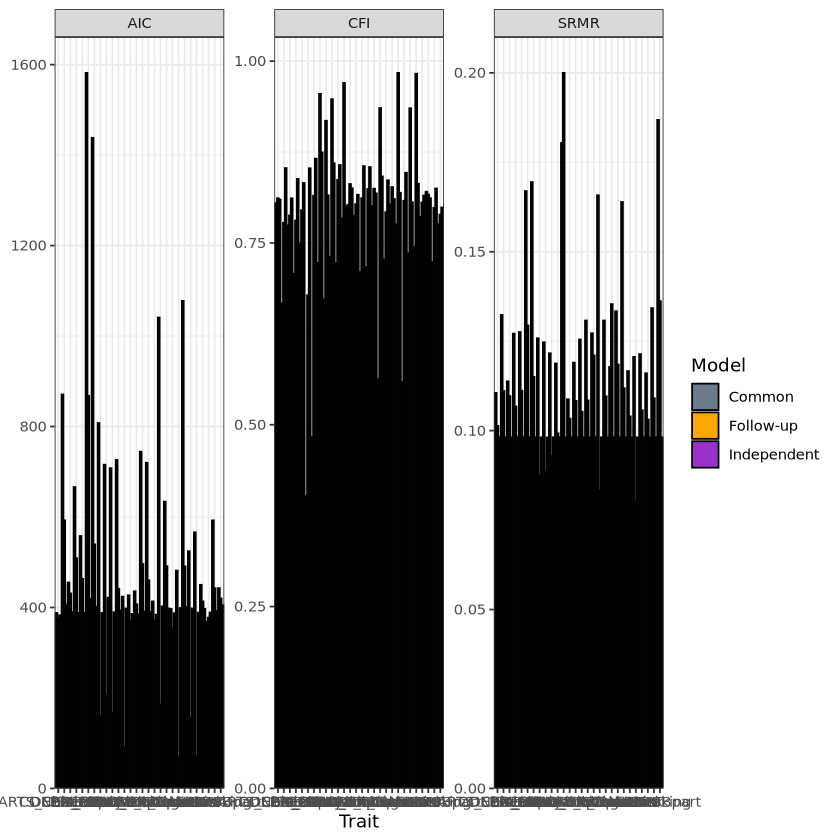

In [62]:
modelfit_follow_up_plot <- ggplot(follow_up_complete, aes(x = Trait, y = Value, fill = Model)) +
geom_col(position = position_dodge(), color = "black") + 
theme_bw() + 
facet_wrap(facets = vars(Metric), nrow = 1, ncol = 3, scales = "free") +
scale_fill_manual(values = c("slategray4","orange", "darkorchid")) +
scale_y_continuous(expand = expansion(mult = c(0,0.05))) +
theme(axis.title.y = element_blank())

modelfit_follow_up_plot

In [63]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/modelfit_follow_up.svg", modelfit_follow_up_plot, width = 20, height = 6)

In [64]:
follow_up_long <- bind_rows(fit_table_follow, fit_table_common, fit_table_independent) %>% subset(select = -c(chisq, df, p_chisq)) %>% arrange(Trait)
follow_up_long

,Trait,AIC,CFI,SRMR,Model
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
df...1,ARTS_Cheesman,376.3728,0.8114798,0.10132798,Follow-up
df...2,ARTS_Cheesman,387.8349,0.8046178,0.11055716,Common
df...3,ARTS_Cheesman,382.7507,0.8096198,0.09814238,Independent
df...4,BMI,592.5617,0.7777724,0.11107561,Follow-up
df...5,BMI,870.8302,0.6666635,0.13233694,Common
df...6,BMI,406.5744,0.8529623,0.09814236,Independent
df...7,CONSC_Gupta,430.9681,0.7877266,0.10964110,Follow-up
df...8,CONSC_Gupta,455.2485,0.7742082,0.11377011,Common
df...9,CONSC_Gupta,389.7662,0.8113630,0.09814233,Independent


Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


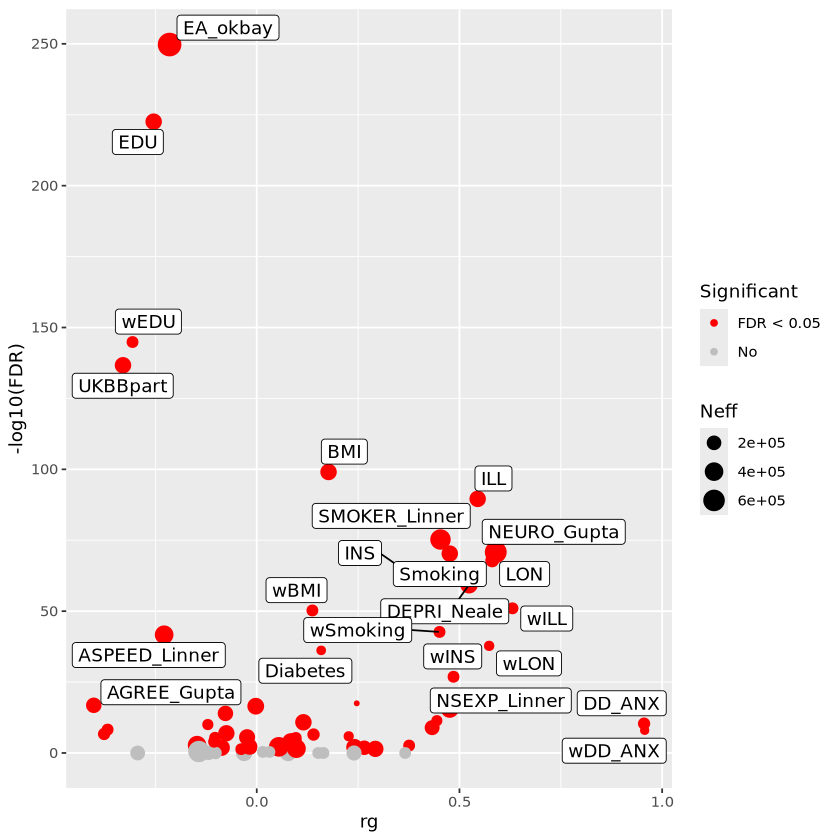

In [65]:
#make the chi squared plot but with the common factor correlation of the external trait on the x axis
rg_chisq_plot <- ggplot(filter(target_rg, Mental == "F1"), aes(x = rg, y = -log10(FDR), label = trait)) +
geom_point(aes(color = Significant, size = Neff)) + 
scale_color_manual(values = c("red","gray")) +
geom_label_repel()

rg_chisq_plot

In [66]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/rg_chisq_plot.svg", rg_chisq_plot, device = svg)

Saving 6.67 x 6.67 in image
Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [67]:
unique(target_rg$trait)

[1] "AGREE_Gupta"     "AGRI_Cheesman"   "ALC"             "ARTS_Cheesman"  
 [5] "ASPEED_Linner"   "BMI"             "BP"              "BUSI_Cheesman"  
 [9] "Cancer"          "Coffee"          "CONSC_Gupta"     "DD_ANX"         
[13] "DEPRI_Neale"     "Diabetes"        "DRINKS_Linner"   "EA_okbay"       
[17] "EDU_Cheesman"    "EDU"             "ENG_Cheesman"    "EXTRA_Gupta"    
[21] "Fruit"           "Health_Cheesman" "Height"          "ICT_Cheesman"   
[25] "ILL"             "INS"             "LDL"             "LON"            
[29] "NatSci_Cheesman" "NEURO_Gupta"     "NSEXP_Linner"    "OPEN_Gupta"     
[33] "PA"              "REPERR_Schoeler" "Risk"            "RT"             
[37] "SERV_Cheesman"   "Sex"             "SMOKER_Linner"   "Smoking"        
[41] "Social_Cheesman" "UKBBpart"        "VEG"             "wALC"           
[45] "wBMI"            "wBP"             "wCancer"         "wCoffee"        
[49] "wDD_ANX"         "wDiabetes"       "wEDU"            "wFruit"         
[53] "wHeight"         "wILL"            "wINS"            "wLDL"           
[57] "wLON"            "wPA"             "wRisk"           "wRT"            
[61] "wSex"            "wSmoking"        "wUKBBpart"       "wVEG"

In [68]:
#grouped rg plot 
grouped_traits <- list(
    "BIG 5" = c("AGREE_Gupta", "EXTRA_Gupta", "OPEN_Gupta", "NEURO_Gupta", "CONSC_Gupta"),
    "Educational Fields & Educational Attainment" = c("AGRI_Cheesman", "ARTS_Cheesman", "EDU_Cheesman", "ENG_Cheesman", "Health_Cheesman", "BUSI_Cheesman", "ICT_Cheesman", "NatSci_Cheesman", "SERV_Cheesman", "Social_Cheesman", "EA_okbay", "EDU", "wEDU"),
    "Behavior" = c("ALC", "wALC", "Coffee", "wCoffee", "ASPEED_Linner", "DRINKS_Linner", "Fruit", "wFruit", "LON", "wLON", "NSEXP_Linner", "PA", "wPA", "SMOKER_Linner", "Smoking", "wSmoking", "VEG", "wVEG"),
    "Health Data and Diseases" = c("Sex", "wSex", "BMI", "wBMI", "BP", "wBP", "Cancer", "wCancer", "DD_ANX", "wDD_ANX", "Diabetes", "wDiabetes", "Height", "wHeight", "ILL", "wILL", "INS", "wINS", "LDL", "wLDL", "Risk", "wRisk", "RT", "wRT"),
    "Others" = c("DEPRI_Neale", "REPERR_Schoeler", "UKBBpart", "wUKBBpart")
    )

In [69]:
length(unique(target_rg$trait))

[1] 64

In [70]:
total_len <- 0
combined <- c()
for (i in 1:5){
    a <- grouped_traits[[i]]
    len_a <- length(a)
    combined <- c(combined, a)
    total_len <- total_len + len_a
}
print(total_len)
unique(target_rg$trait)[!unique(target_rg$trait) %in% combined]

[1] 64


character(0)

In [71]:
#grouped rg plot 
common_rg_df <- filter(target_rg, Mental == "F1")

common_rg_df_annotated <- mutate(common_rg_df, Group = case_when(
    trait %in% grouped_traits[["BIG 5"]] ~ "BIG 5",
    trait %in% grouped_traits[["Educational Fields & Educational Attainment"]] ~ "Educational Fields & Educational Attainment",
    trait %in% grouped_traits[["Behavior"]] ~ "Behavior",
    trait %in% grouped_traits[["Health Data and Diseases"]] ~ "Health Data and Diseases",
    trait %in% grouped_traits[["Others"]] ~ "Others"
    )
)

In [72]:
common_rg_df_annotated

trait,Pathway,Mental,rg,se,N,q_chisq,q_df,q_p,FDR,Sample_Prevalence,Population_Prevalence,Neff,Significant,Group
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AGREE_Gupta,Common,F1,-0.402036147,0.03957293,1138711.2,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.00,FDR < 0.05,BIG 5
AGRI_Cheesman,Common,F1,-0.376585998,0.06314591,231726.1,38.177299,4,1.030044e-07,1.997660e-07,0.50000000,0.0327,114687.80,FDR < 0.05,Educational Fields & Educational Attainment
ALC,Common,F1,0.077385362,0.03110010,1248722.4,-7.366641,4,1.000000e+00,1.000000e+00,NA,NA,283162.00,No,Behavior
ARTS_Cheesman,Common,F1,0.265233029,0.05582720,302092.7,13.084177,4,1.087173e-02,1.449564e-02,0.50000000,0.0509,194834.29,FDR < 0.05,Educational Fields & Educational Attainment
ASPEED_Linner,Common,F1,-0.228435959,0.02642698,1491981.2,203.970805,4,5.261120e-43,2.104448e-42,NA,NA,404291.00,FDR < 0.05,Behavior
BMI,Common,F1,0.177104710,0.02054742,1250015.9,472.255877,4,6.697642e-101,8.572982e-100,NA,NA,283749.00,FDR < 0.05,Health Data and Diseases
BP,Common,F1,-0.031273275,0.02617695,1232366.8,-5.394028,4,1.000000e+00,1.000000e+00,NA,NA,275793.00,No,Health Data and Diseases
BUSI_Cheesman,Common,F1,-0.147202002,0.06141226,431234.2,18.256854,4,1.099301e-03,1.675125e-03,0.50000000,0.1460,397458.52,FDR < 0.05,Educational Fields & Educational Attainment
Cancer,Common,F1,0.241073811,0.07059937,1248440.1,14.320820,4,6.338486e-03,8.818763e-03,NA,NA,283034.00,FDR < 0.05,Health Data and Diseases


In [73]:
#make the grouped barplot
group_colors <- c(
  "BIG 5" = "#E69F00",
  "Educational Fields & Educational Attainment" = "#56B4E9",
  "Behavior" = "#009E73",
  "Health Data and Diseases" = "#0072B2",
  "Others" = "#D55E00"
)

common_rg_df_annotated <- arrange(common_rg_df_annotated, Group, desc(rg)) %>% group_by(Group, desc(rg)) %>% mutate(trait = factor(trait, levels = trait), Group = factor(Group, levels = unique(Group)))

dput(x = common_rg_df_annotated, file = here::here("bias_stuff","rg_table_patrick_annotated.R"))


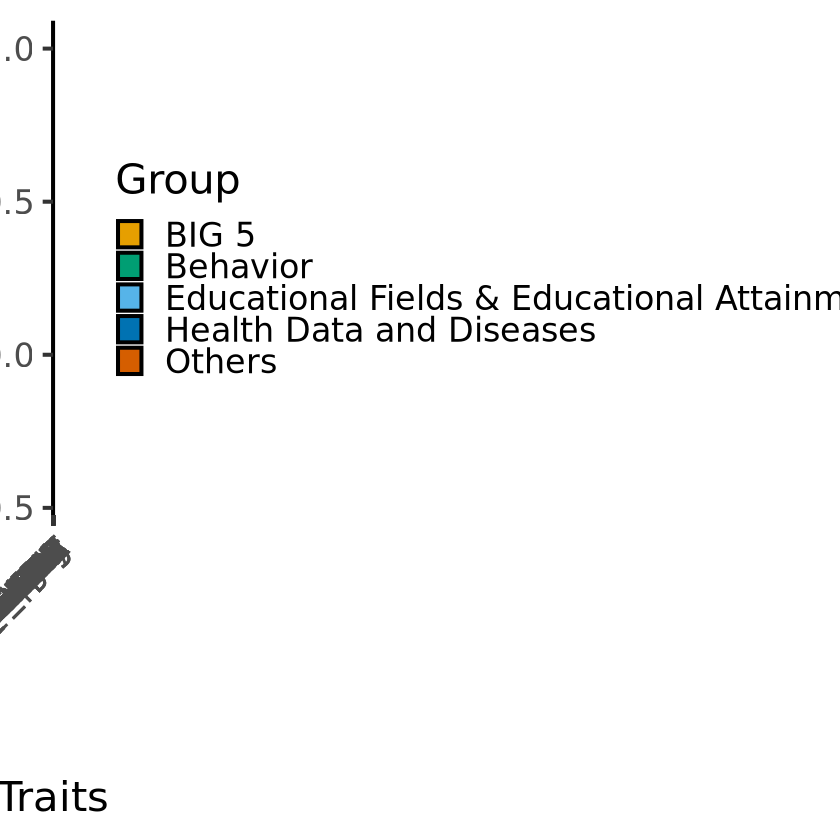

In [74]:
grouped_common_factor_rg <- ggplot(common_rg_df_annotated, aes(x = as.factor(trait), y = rg, fill = Group)) +
scale_fill_manual(values = group_colors) +
geom_col(color = "black") +
geom_errorbar(aes(ymin = rg - se, ymax = rg + se), width = 0.5) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(y = expression(italic(r[g])), x = "Traits")

grouped_common_factor_rg

In [75]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/grouped_common_factor_correlation.pdf", grouped_common_factor_rg, device = pdf, width = 30, height = 15)

In [76]:
write_csv(common_rg_df_annotated, file = "/local1/home/pazweifel/plots/jolien_extra_bias/factor_correlations_table.csv")

In [77]:
head(common_rg_df_annotated)

trait,Pathway,Mental,rg,se,N,q_chisq,q_df,q_p,FDR,Sample_Prevalence,Population_Prevalence,Neff,Significant,Group,desc(rg)
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>
NEURO_Gupta,Common,F1,0.589577559,0.03198894,1853183,340.542837,4,1.930845e-72,1.544676e-71,NA,NA,623482,FDR < 0.05,BIG 5,-0.589577559
OPEN_Gupta,Common,F1,0.240033111,0.03995996,1100828,-3.058664,4,1.000000e+00,1.000000e+00,NA,NA,220015,No,BIG 5,-0.240033111
EXTRA_Gupta,Common,F1,-0.002455395,0.03208017,1278489,85.658984,4,1.099396e-17,3.198244e-17,NA,NA,298772,FDR < 0.05,BIG 5,0.002455395
CONSC_Gupta,Common,F1,-0.077236523,0.03428345,1137515,73.482289,4,4.171946e-15,1.112519e-14,NA,NA,234880,FDR < 0.05,BIG 5,0.077236523
AGREE_Gupta,Common,F1,-0.402036147,0.03957293,1138711,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374,FDR < 0.05,BIG 5,0.402036147
LON,Common,F1,0.580821378,0.03325131,1241600,326.502236,4,2.072281e-69,1.326260e-68,0.180757,0.2034,165819,FDR < 0.05,Behavior,-0.580821378


## jolien analysis as a comparison (different sumstats including UKBB)

In [78]:
rg_table_jolien <- read_delim("
p1 p2 rg se z p h2_obs h2_obs_se h2_int h2_int_se gcov_int gcov_int_se
common-factor AGREE_Gupta -0.2008 0.0729 -2.7548 0.0059 0.05 0.0139 0.9877 0.0362 -0.0172 0.0144
common-factor AGRI_Cheesman -0.3876 0.1152 -3.3645 0.0008 0.4047 0.1195 0.9931 0.0144 0.0251 0.012
common-factor ALC 0.1389 0.0478 2.9058 0.0037 0.0594 0.0122 1.0567 0.0308 -0.0006 0.0126
common-factor ARTS_Cheesman 0.2289 0.0726 3.1544 0.0016 0.541 0.1718 0.97 0.0324 0.0136 0.0122
common-factor ASPEED_Linner -0.1808 0.0456 -3.9615 7.4468e-05 0.0585 0.0094 1.0512 0.038 -0.0282 0.0128
common-factor BMI 0.0201 0.0283 0.7099 0.4777 0.284 0.0427 0.9679 0.1262 -0.0042 0.0158
common-factor BP -0.0078 0.0359 -0.2174 0.8279 0.129 0.0229 1.0542 0.0688 -0.0248 0.0128
common-factor BUSI_Cheesman -0.0357 0.0873 -0.409 0.6826 0.1761 0.0373 1.0057 0.0156 -0.0138 0.0137
common-factor Cancer 0.1022 0.068 1.5024 0.133 0.0226 0.0103 0.9931 0.0362 -0.0002 0.0108
common-factor Coffee -0.0035 0.0521 -0.0667 0.9469 0.0529 0.0099 1.0083 0.0256 -0.016 0.0123
common-factor CONSC_Gupta 0.0105 0.0604 0.1739 0.862 0.0521 0.006 1.026 0.0169 -0.0025 0.0132
common-factor DD_ANX 0.7779 0.1379 5.6407 1.6933e-08 0.0325 0.0107 0.9923 0.0359 0.1592 0.0119
common-factor DEPRI_Neale 0.2844 0.0532 5.3491 8.8404e-08 0.0306 0.004 1.0431 0.015 0.0479 0.0108
common-factor Diabetes -0.0497 0.0546 -0.9087 0.3635 0.0431 0.0054 1.0443 0.0227 0.0201 0.0119
common-factor DRINKS_Linner 0.1615 0.0446 3.6201 0.0003 0.0587 0.0099 1.0631 0.036 -0.0099 0.0132
common-factor EA_okbay 0.0065 0.0329 0.1983 0.8428 0.1211 0.0091 1.2317 0.0669 -0.0182 0.0173
common-factor EDU_Cheesman -0.0538 0.1238 -0.4343 0.6641 0.1765 0.0708 1.0217 0.0135 0.0027 0.0123
common-factor EDU -0.0657 0.0369 -1.7806 0.075 0.1852 0.014 1.318 0.0411 -0.0241 0.0164
common-factor ENG_Cheesman -0.0533 0.0826 -0.6445 0.5193 0.1398 0.0248 1.0183 0.015 -0.0381 0.0146
common-factor EXTRA_Gupta -0.0662 0.0575 -1.1514 0.2496 0.0478 0.0053 1.0545 0.0177 0.0006 0.0132
common-factor Fruit -0.0581 0.045 -1.292 0.1964 0.0651 0.0058 0.9995 0.0175 0.0047 0.012
common-factor Health_Cheesman 0.1307 0.0915 1.4274 0.1535 0.0944 0.0296 1.0449 0.0149 -0.0205 0.012
common-factor Height -0.0662 0.0275 -2.4029 0.0163 0.4279 0.0372 1.3934 0.117 -0.0068 0.0176
common-factor ICT_Cheesman -0.1434 0.0957 -1.4982 0.1341 0.4085 0.1053 1.0024 0.0139 0.0133 0.0128
common-factor ILL 0.3152 0.051 6.1741 6.6554e-10 0.0657 0.0065 1.0699 0.0227 0.0686 0.0134
common-factor INS 0.1841 0.0464 3.9695 7.2013e-05 0.0617 0.0056 1.0219 0.018 0.0473 0.0127
common-factor LDL -0.0332 0.0412 -0.8065 0.42 0.08 0.0179 1.2132 0.1023 -0.0069 0.0121
common-factor LON 0.3555 0.0641 5.5479 2.8913e-08 0.032 0.0046 1.0291 0.016 0.0828 0.0115
common-factor NatSci_Cheesman -0.1147 0.1035 -1.1086 0.2676 0.3534 0.145 1.014 0.0132 0.0074 0.0115
common-factor NEURO_Gupta 0.5111 0.0532 9.6003 7.9673e-22 0.0665 0.0102 1.1267 0.0504 0.1622 0.0186
common-factor NSEXP_Linner 0.318 0.0435 7.3065 2.7422e-13 0.1027 0.0148 1.0204 0.0584 0.045 0.0152
common-factor OPEN_Gupta 0.255 0.0622 4.1018 4.0990e-05 0.0472 0.0058 1.0026 0.0155 0.0116 0.0128
common-factor PA 0.011 0.0628 0.1755 0.8607 0.0343 0.0043 1.0305 0.0132 0.0129 0.0111
common-factor REPERR_Schoeler -0.0117 0.1552 -0.0752 0.9401 0.0182 0.0144 1.03 0.0117 0.0069 0.0098
common-factor Risk 0.3557 0.0666 5.3445 9.0690e-08 0.0524 0.0087 1.0102 0.0257 0.013 0.0137
common-factor RT 0.2099 0.0486 4.3205 1.5567e-05 0.0535 0.0055 1.0535 0.0184 0.0229 0.0119
common-factor SERV_Cheesman -0.5148 0.6331 -0.8131 0.4162 0.0312 0.0613 1.0265 0.0132 0.0141 0.0128
common-factor Sex 0.0402 0.0874 0.4602 0.6454 0.0159 0.0129 0.9924 0.0414 -0.002 0.0123
common-factor SMOKER_Linner 0.3155 0.0364 8.6745 4.1540e-18 0.0881 0.0055 1.0451 0.0299 0.0403 0.0139
common-factor Smoking 0.328 0.0441 7.4388 1.0158e-13 0.0952 0.0086 1.063 0.0275 0.0359 0.0136
common-factor Social_Cheesman 0.1141 0.0856 1.3327 0.1826 0.4304 0.1724 0.9777 0.0202 0.0029 0.0118
common-factor UKBBpart -0.0554 0.0477 -1.1624 0.2451 0.0924 0.0071 1.0805 0.0215 -0.0481 0.0149
common-factor VEG 0.1692 0.0789 2.1448 0.032 0.0273 0.0129 1.0187 0.0424 0.0149 0.012
common-factor wALC 0.1801 0.0903 1.9949 0.0461 0.0431 0.0146 1.0206 0.0166 -0.0051 0.012
common-factor wBMI -0.0114 0.0353 -0.3225 0.7471 0.2565 0.0438 0.9415 0.0463 -0.0086 0.0124
common-factor wBP -0.0151 0.0534 -0.2822 0.7778 0.1379 0.0376 1.0143 0.0411 -0.0224 0.0111
common-factor wCancer 0.2798 0.2385 1.1735 0.2406 0.0074 0.0088 1.0096 0.011 -0.0089 0.0129
common-factor wCoffee 0.0811 0.1112 0.7291 0.4659 0.0258 0.0142 1.0253 0.0151 -0.0162 0.0109
common-factor wDD_ANX 0.9158 0.2263 4.0461 5.2072e-05 0.0249 0.01 1.0201 0.0136 0.0848 0.0134
common-factor wDiabetes 0.0432 0.0863 0.501 0.6164 0.0455 0.0096 1.0171 0.0124 -0.0029 0.0118
common-factor wEDU -0.1641 0.0565 -2.9026 0.0037 0.216 0.0215 1.116 0.0225 -0.0164 0.0165
common-factor wFruit -0.0614 0.0661 -0.9296 0.3526 0.0758 0.0161 0.9865 0.0176 -0.0105 0.0121
common-factor wHeight -0.0771 0.0363 -2.1253 0.0336 0.4094 0.037 1.126 0.0424 -0.0029 0.0137
common-factor wILL 0.3659 0.1005 3.642 0.0003 0.0601 0.0281 1.0156 0.0329 0.0458 0.0108
common-factor wINS 0.3543 0.0757 4.6794 2.8772e-06 0.0564 0.0105 1.0216 0.0133 0.0228 0.012
common-factor wLDL -0.0626 0.0647 -0.9676 0.3332 0.0725 0.0335 1.1 0.064 -0.0014 0.0114
common-factor wLON 0.0955 0.1725 0.5535 0.58 0.3419 0.6597 0.5852 0.9737 0.0651 0.0143
common-factor wPA 0.0268 0.0831 0.3221 0.7474 0.0532 0.0257 0.9692 0.0296 -0.0022 0.0116
common-factor wRisk 0.4007 0.137 2.9244 0.0035 0.0303 0.0118 1.033 0.0135 0.0217 0.0127
common-factor wRT 0.2556 0.0766 3.336 0.0008 0.0629 0.012 1.0089 0.0137 0.0064 0.0121
common-factor wSex 0.1443 0.1627 0.8864 0.3754 0.0143 0.0092 1.0006 0.0116 0.0073 0.0114
common-factor wSmoking 0.3232 0.0674 4.7964 1.6151e-06 0.0779 0.012 1.0388 0.0145 0.0301 0.0114
common-factor wUKBBpart -0.0656 0.1821 -0.3601 0.7188 0.0153 0.0098 1.039 0.0124 -0.0181 0.0143
common-factor wVEG NA NA NA NA -0.0094 0.0255 1.0371 0.0281 -0.0043 0.01
",
delim = " ") 

Rows: 64 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: " "
chr  (2): p1, p2
dbl (10): rg, se, z, p, h2_obs, h2_obs_se, h2_int, h2_int_se, gcov_int, gcov...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [79]:
head(rg_table_jolien)

p1,p2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
common-factor,AGREE_Gupta,-0.2008,0.0729,-2.7548,5.9000e-03,0.0500,0.0139,0.9877,0.0362,-0.0172,0.0144
common-factor,AGRI_Cheesman,-0.3876,0.1152,-3.3645,8.0000e-04,0.4047,0.1195,0.9931,0.0144,0.0251,0.0120
common-factor,ALC,0.1389,0.0478,2.9058,3.7000e-03,0.0594,0.0122,1.0567,0.0308,-0.0006,0.0126
common-factor,ARTS_Cheesman,0.2289,0.0726,3.1544,1.6000e-03,0.5410,0.1718,0.9700,0.0324,0.0136,0.0122
common-factor,ASPEED_Linner,-0.1808,0.0456,-3.9615,7.4468e-05,0.0585,0.0094,1.0512,0.0380,-0.0282,0.0128
common-factor,BMI,0.0201,0.0283,0.7099,4.7770e-01,0.2840,0.0427,0.9679,0.1262,-0.0042,0.0158


In [80]:
rg_table_jolien_annotated <- mutate(rg_table_jolien, Group = case_when(
    p2 %in% grouped_traits[["BIG 5"]] ~ "BIG 5",
    p2 %in% grouped_traits[["Educational Fields & Educational Attainment"]] ~ "Educational Fields & Educational Attainment",
    p2 %in% grouped_traits[["Behavior"]] ~ "Behavior",
    p2 %in% grouped_traits[["Health Data and Diseases"]] ~ "Health Data and Diseases",
    p2 %in% grouped_traits[["Others"]] ~ "Others"
    )
)

In [81]:
#make the grouped barplot
group_colors <- c(
  "BIG 5" = "#E69F00",
  "Educational Fields & Educational Attainment" = "#56B4E9",
  "Behavior" = "#009E73",
  "Health Data and Diseases" = "#0072B2",
  "Others" = "#D55E00"
)

rg_table_jolien_annotated <- rg_table_jolien_annotated %>% 
slice(match(common_rg_df_annotated$trait, p2)) %>% 
mutate(trait = factor(p2, levels = p2), Group = factor(Group, levels = unique(Group)))

dput(x = rg_table_jolien_annotated, file = here::here("bias_stuff","rg_table_jolien_annotated.R"))

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


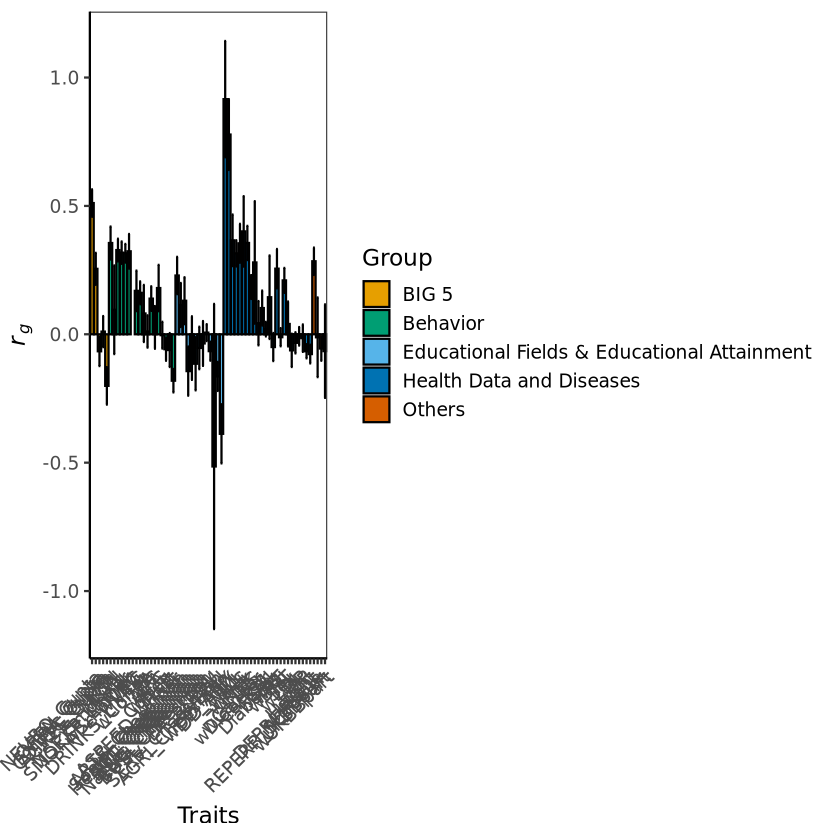

In [82]:
jolien_common_factor_rg_plot <- ggplot(rg_table_jolien_annotated, aes(x = as.factor(trait), y = rg, fill = Group)) +
scale_fill_manual(values = group_colors) +
geom_col(color = "black") +
geom_errorbar(aes(ymin = rg - se, ymax = rg + se), width = 0.5) +
theme_bw(base_size = 14) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), 
     axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(y = expression(italic(r[g])), x = "Traits")

jolien_common_factor_rg_plot

### Corrected correlaiton plot P factor

In [83]:
rg_table_p <- read_table("/local1/home/pazweifel/src/common_factor_jolien/rg_results/rg_summary.tsv")


── Column specification ────────────────────────────────────────────────────────
cols(
  trait = col_character(),
  rg = col_double(),
  se = col_double(),
  z = col_double(),
  p = col_double()
)



In [84]:
rg_table_p_annotated <- mutate(rg_table_p, Group = case_when(
    trait %in% grouped_traits[["BIG 5"]] ~ "BIG 5",
    trait %in% grouped_traits[["Educational Fields & Educational Attainment"]] ~ "Educational Fields & Educational Attainment",
    trait %in% grouped_traits[["Behavior"]] ~ "Behavior",
    trait %in% grouped_traits[["Health Data and Diseases"]] ~ "Health Data and Diseases",
    trait %in% grouped_traits[["Others"]] ~ "Others"
    )
)

In [85]:
#make the grouped barplot
group_colors <- c(
  "BIG 5" = "#E69F00",
  "Educational Fields & Educational Attainment" = "#56B4E9",
  "Behavior" = "#009E73",
  "Health Data and Diseases" = "#0072B2",
  "Others" = "#D55E00"
)

rg_table_p_annotated <- rg_table_p_annotated %>% arrange(Group, desc(rg)) %>% group_by(Group, desc(rg)) %>% mutate(trait = factor(trait, levels = trait), Group = factor(Group, levels = unique(Group)))



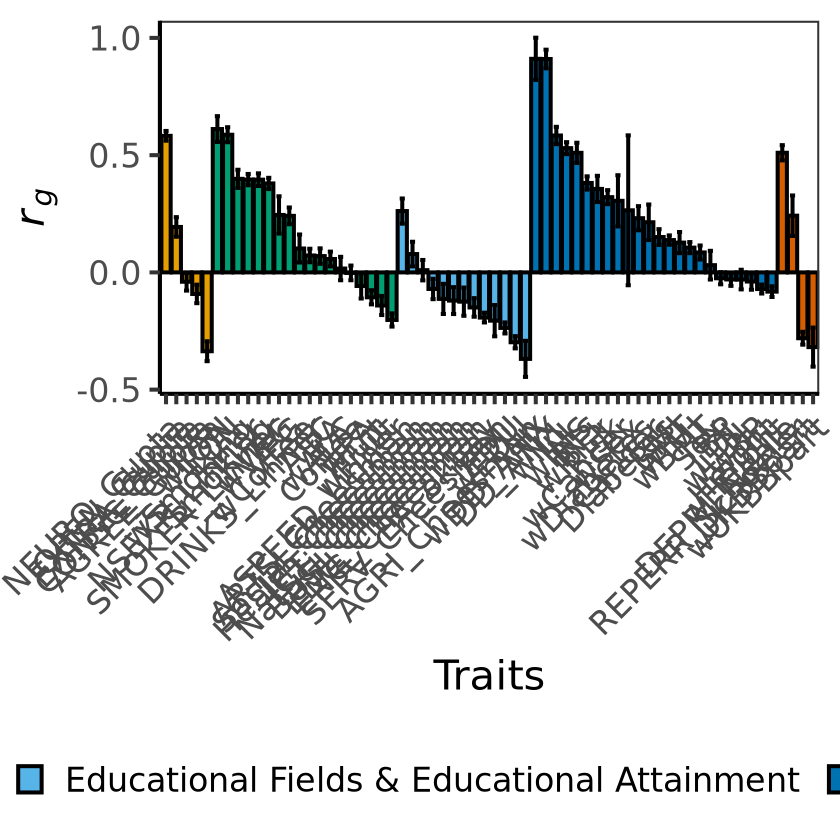

In [86]:
jolien_common_factor_rg_plot <- ggplot(rg_table_p_annotated, aes(x = as.factor(trait), y = rg, fill = Group)) +
scale_fill_manual(values = group_colors) +
geom_col(color = "black") +
geom_errorbar(aes(ymin = rg - se, ymax = rg + se), width = 0.5) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), 
     axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "bottom") +
labs(y = expression(italic(r[g])), x = "Traits")

jolien_common_factor_rg_plot

In [87]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/grouped_common_factor_correlation_corrected.pdf", plot = jolien_common_factor_rg_plot, device = "pdf", width = 30, height = 15)

In [88]:
write_csv(rg_table_p_annotated, "/local1/home/pazweifel/plots/jolien_extra_bias/common_factor_correlations.csv")

### Combined plot

In [89]:
library(cowplot)

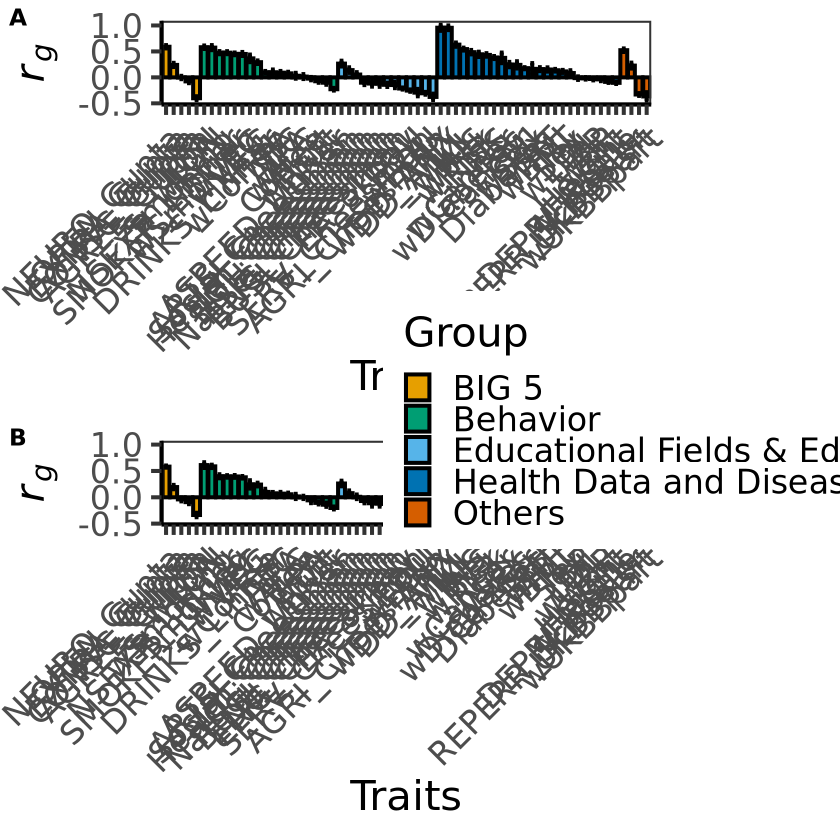

In [90]:
common_legend <- get_legend(grouped_common_factor_rg)

grouped_common_factor_rg_wl <- grouped_common_factor_rg + theme(legend.position = "none")

jolien_common_factor_rg_plot_wl <- jolien_common_factor_rg_plot + theme(legend.position = "none")

combined_plot_rg_wl <- plot_grid(plotlist = list(grouped_common_factor_rg_wl, jolien_common_factor_rg_plot_wl),label_size = 14, nrow = 2,
                              labels = c("A", "B"))
combined_plot_rg <- plot_grid(
    plotlist = list(combined_plot_rg_wl, common_legend),
    ncol = 2,
    rel_widths = c(1, 0.25)
    )

combined_plot_rg

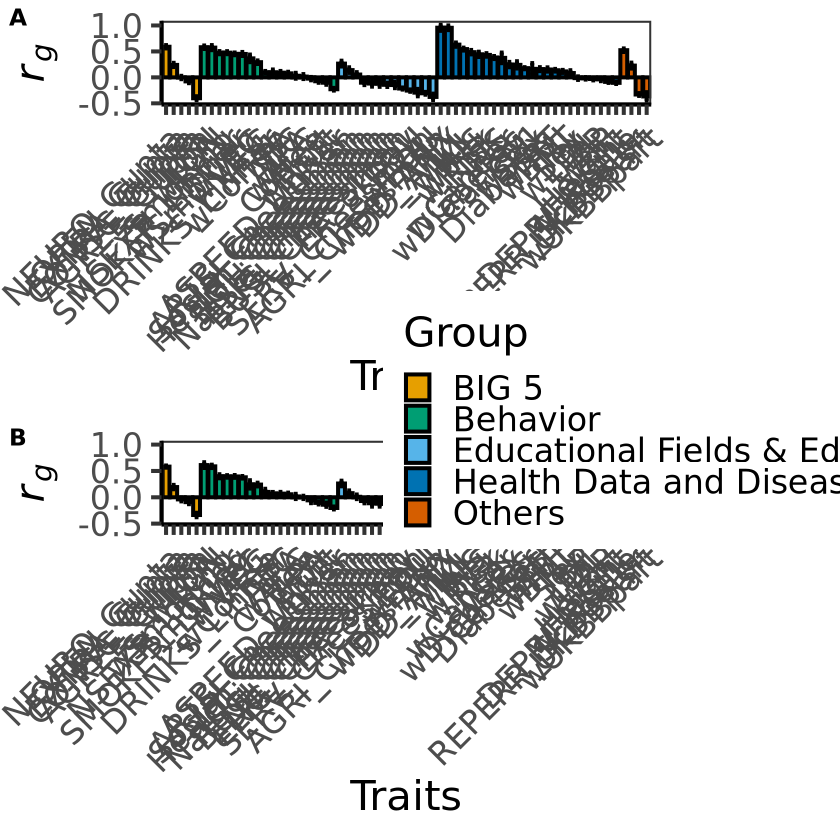

In [91]:
combined_plot_rg

In [92]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/combined_rg_plot_jol_onelegend_pazw.pdf", combined_plot_rg, device = pdf, width = 20, height = 15, useDingbats = FALSE)

In [93]:
combined_df_jol_pazw <- common_rg_df_annotated
combined_df_jol_pazw$rg_jol <- rg_table_jolien_annotated$rg
combined_df_jol_pazw$se_jol <- rg_table_jolien_annotated$se

In [94]:
rgs_correlation <- cor.test(combined_df_jol_pazw$rg, combined_df_jol_pazw$rg_jol, method = "pearson")
pearson_r <- round(rgs_correlation$estimate[[1]], 2)
pearson_p <- rgs_correlation$p.value


In [95]:
format_p <- function(p){
    p_split <- str_split_1(as.character(p), pattern = "e")
    base <- round(as.numeric(p_split[1]), 2)
    exp <- as.numeric(p_split[2])
    formated <- bquote(.(base) %*% 10^.(exp))
    formated
}

In [96]:
pearson_labels <- bquote(
    italic(r[pearson]) == .(pearson_r) ~ "," ~
    italic(p) == .(format_p(pearson_p))
    )

Warning message in geom_point(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, :
“Ignoring unknown aesthetics: label”
Warning message in geom_errorbar(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, :
“Ignoring unknown aesthetics: label”
Warning message in geom_errorbar(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, :
“Ignoring unknown aesthetics: label”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
`height` was translated to `width`.
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“ggrepel: 58 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


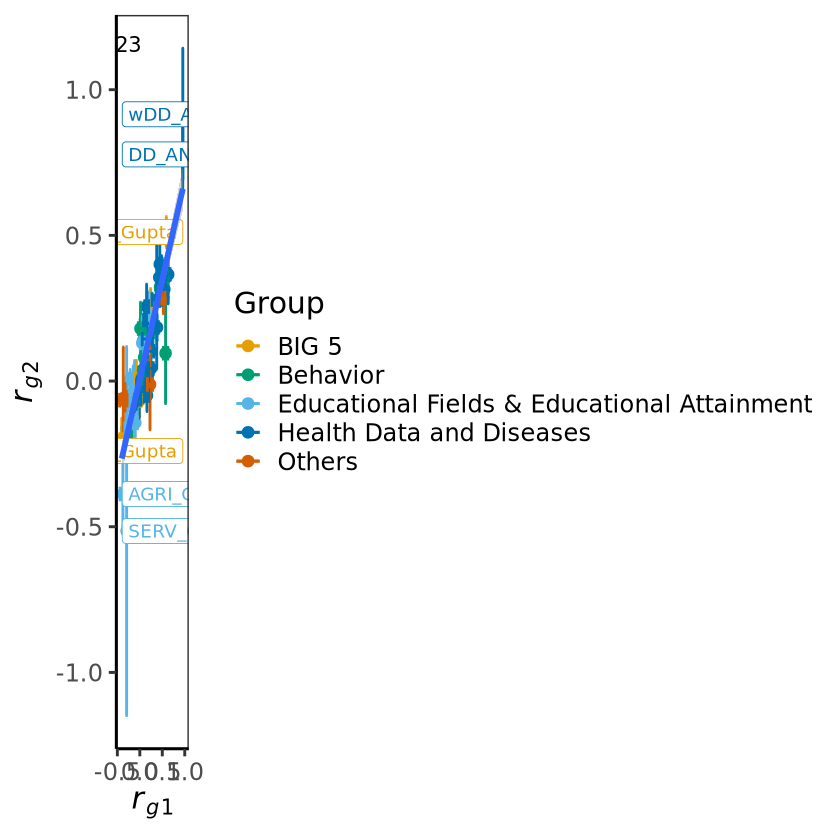

In [97]:
scatterplot_combined_jol_pazw <- ggplot() +
geom_point(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, color = Group, label = trait)) +
scale_color_manual(values = group_colors) +
geom_errorbar(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, color = Group, label = trait, ymin = rg_jol - se_jol, ymax = rg_jol + se_jol), width = 0.05) +
geom_errorbar(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, color = Group, label = trait, xmin = rg - se, xmax = rg + se), height = 0.05) +
annotate("text", x = Inf, y = Inf, label = deparse(pearson_labels), parse = TRUE, hjust = 1.1, vjust = 1.5) +
theme_bw(base_size = 18) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black")) +
labs(y = expression(italic(r[g2])), x = expression(italic(r[g1]))) +
geom_label_repel(combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol, color = Group, label = trait), show.legend = FALSE) +
geom_smooth(data = combined_df_jol_pazw, mapping = aes(x = rg, y = rg_jol), method = "lm", se = TRUE) 

scatterplot_combined_jol_pazw

In [98]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/scatterplot_rg_jol_pazw.pdf", scatterplot_combined_jol_pazw, device = pdf, width = 20, height = 15, useDingbats = FALSE)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
`height` was translated to `width`.
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“ggrepel: 15 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [99]:
#load the metadata file
metadata <- read_csv("/local1/scratch/pazweifel/sumstats_covariates/metadata_annotated_ref.csv", col_names = TRUE)

Rows: 64 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Phenotype, Description, REF
dbl (4): N, Sample_Prevalence, Population_Prevalence, Neff

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [100]:
metadata_wgroup <- mutate(metadata, Group = case_when(
    Phenotype %in% grouped_traits[["BIG 5"]] ~ "BIG 5",
    Phenotype %in% grouped_traits[["Educational Fields & Educational Attainment"]] ~ "Educational Fields & Educational Attainment",
    Phenotype %in% grouped_traits[["Behavior"]] ~ "Behavior",
    Phenotype %in% grouped_traits[["Health Data and Diseases"]] ~ "Health Data and Diseases",
    Phenotype %in% grouped_traits[["Others"]] ~ "Others"
    )
)

In [101]:
write_csv(x = metadata_wgroup, "/local1/scratch/pazweifel/sumstats_covariates/metadata_complete.csv", col_names = TRUE)

In [102]:
write_csv(metadata_wgroup, file = "/local1/home/pazweifel/plots/jolien_extra_bias/metadata_external_phenotypes.csv")

In [103]:
rg_df_export <- common_rg_df_annotated %>% subset(select = c(trait, rg, se)) %>% rename(Phenotype = trait)

In [104]:
write_csv("/local1/scratch/pazweifel/sumstats_covariates/common_factor_rgs_jolien.csv", x = rg_df_export, col_names = TRUE)

### Factor sumstats jolien adjustment

In [105]:
factor_sumstats <- read_delim("/local1/home/pazweifel/src/common_factor_jolien/mental_common_factor_filtered.tsv.gz",delim = " ")

Rows: 5916624 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: " "
chr  (6): SNP, A1, A2, lhs, op, rhs
dbl (13): CHR, BP, MAF, i, est, se_c, Z_Estimate, Pval_Estimate, Q, Q_df, Q_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [106]:
head(factor_sumstats)

SNP,CHR,BP,MAF,A1,A2,i,lhs,op,rhs,est,se_c,Z_Estimate,Pval_Estimate,Q,Q_df,Q_pval,fail,warning
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs11240777,1,798959,0.204771,G,A,1,F1,~,SNP,-0.0019838622,0.002331488,-0.85089948,0.3948252,3.175472,4,0.5289018,0,0
rs2340596,1,913889,0.399602,G,A,2,F1,~,SNP,-0.0010138143,0.001880507,-0.53911760,0.5898057,7.147791,4,0.1282812,0,0
rs6677020,1,920648,0.040755,T,C,3,F1,~,SNP,0.0001710319,0.005076293,0.03369228,0.9731225,5.847281,4,0.2108474,0,0
rs6677131,1,920733,0.040755,T,C,4,F1,~,SNP,-0.0002265064,0.005081240,-0.04457698,0.9644445,7.087581,4,0.1313317,0,0
rs6662128,1,921570,0.042744,T,C,5,F1,~,SNP,0.0009652065,0.005073987,0.19022646,0.8491317,5.429940,4,0.2459568,0,0
rs6605060,1,923076,0.042744,A,G,6,F1,~,SNP,0.0011177521,0.005042816,0.22165239,0.8245845,5.287547,4,0.2590449,0,0


In [107]:
##Calculate Implied Sample Size for Factor 1
#restrict to MAF >= 10%
factor_sumstats_wn<-subset(factor_sumstats, factor_sumstats$MAF >= .1)

N_hat_F1<-mean(1/((2*factor_sumstats_wn$MAF*(1-factor_sumstats_wn$MAF))*factor_sumstats_wn$se_c^2))

In [108]:
factor_sumstats_wn$N <- N_hat_F1

In [109]:
factor_sumstats_wn <- factor_sumstats_wn %>% select(SNP, CHR, BP, MAF, A1, A2, est, se_c, Pval_Estimate, N) %>% rename(Beta = est, SE = se_c, P = Pval_Estimate)

In [110]:
write_tsv(x = factor_sumstats_wn, file = "/local1/home/pazweifel/src/common_factor_jolien/mental_common_factor_wN.tsv")

### Comparison GSEM-dervived correlations vs Cross-trait LDSC correlations

In [119]:
rg_table_p_annotated <- rg_table_p_annotated %>% 
slice(match(common_rg_df_annotated$trait, trait)) %>% 
mutate(trait = factor(trait, levels = trait), Group = factor(Group, levels = unique(Group)))

In [121]:
combined_df_gsem_ldsc <- common_rg_df_annotated
combined_df_gsem_ldsc$rg_ldsc <- rg_table_p_annotated$rg
combined_df_gsem_ldsc$se_ldsc <- rg_table_p_annotated$se

In [122]:
rgs_correlation <- cor.test(combined_df_gsem_ldsc$rg, combined_df_gsem_ldsc$rg_ldsc, method = "pearson")
pearson_r <- round(rgs_correlation$estimate[[1]], 2)
pearson_p <- rgs_correlation$p.value


In [123]:
format_p <- function(p){
    p_split <- str_split_1(as.character(p), pattern = "e")
    base <- round(as.numeric(p_split[1]), 2)
    exp <- as.numeric(p_split[2])
    formated <- bquote(.(base) %*% 10^.(exp))
    formated
}

In [124]:
pearson_labels <- bquote(
    italic(r[pearson]) == .(pearson_r) ~ "," ~
    italic(p) == .(format_p(pearson_p))
    )

In [127]:
combined_df_gsem_ldsc

trait,Pathway,Mental,rg,se,N,q_chisq,q_df,q_p,FDR,Sample_Prevalence,Population_Prevalence,Neff,Significant,Group,desc(rg),rg_ldsc,se_ldsc
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
NEURO_Gupta,Common,F1,0.589577559,0.03198894,1853183.0,340.542837,4,1.930845e-72,1.544676e-71,NA,NA,623482.00,FDR < 0.05,BIG 5,-0.589577559,0.5824,0.0207
OPEN_Gupta,Common,F1,0.240033111,0.03995996,1100828.4,-3.058664,4,1.000000e+00,1.000000e+00,NA,NA,220015.00,No,BIG 5,-0.240033111,0.1938,0.0417
EXTRA_Gupta,Common,F1,-0.002455395,0.03208017,1278489.2,85.658984,4,1.099396e-17,3.198244e-17,NA,NA,298772.00,FDR < 0.05,BIG 5,0.002455395,-0.0398,0.0378
CONSC_Gupta,Common,F1,-0.077236523,0.03428345,1137515.3,73.482289,4,4.171946e-15,1.112519e-14,NA,NA,234880.00,FDR < 0.05,BIG 5,0.077236523,-0.0919,0.0394
AGREE_Gupta,Common,F1,-0.402036147,0.03957293,1138711.2,87.251516,4,5.048468e-18,1.538581e-17,NA,NA,235374.00,FDR < 0.05,BIG 5,0.402036147,-0.3362,0.0424
LON,Common,F1,0.580821378,0.03325131,1241599.9,326.502236,4,2.072281e-69,1.326260e-68,0.180757,0.2034,165819.01,FDR < 0.05,Behavior,-0.580821378,0.6113,0.0549
wLON,Common,F1,0.573286968,0.04894113,745511.3,185.664190,4,4.527776e-39,1.704574e-38,0.203400,0.2034,65412.83,FDR < 0.05,Behavior,-0.573286968,0.5870,0.0320
Smoking,Common,F1,0.476104208,0.02987135,1250015.9,337.880725,4,7.251523e-72,5.156639e-71,NA,NA,283749.00,FDR < 0.05,Behavior,-0.476104208,0.3990,0.0388
NSEXP_Linner,Common,F1,0.476019048,0.02872186,1428677.0,81.327654,4,9.113463e-17,2.535920e-16,NA,NA,370711.00,FDR < 0.05,Behavior,-0.476019048,0.3958,0.0241


Warning message in geom_point(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, :
“Ignoring unknown aesthetics: label”
Warning message in geom_errorbar(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, :
“Ignoring unknown aesthetics: label”
Warning message in geom_errorbar(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, :
“Ignoring unknown aesthetics: label”
`geom_smooth()` using formula = 'y ~ x'
`height` was translated to `width`.


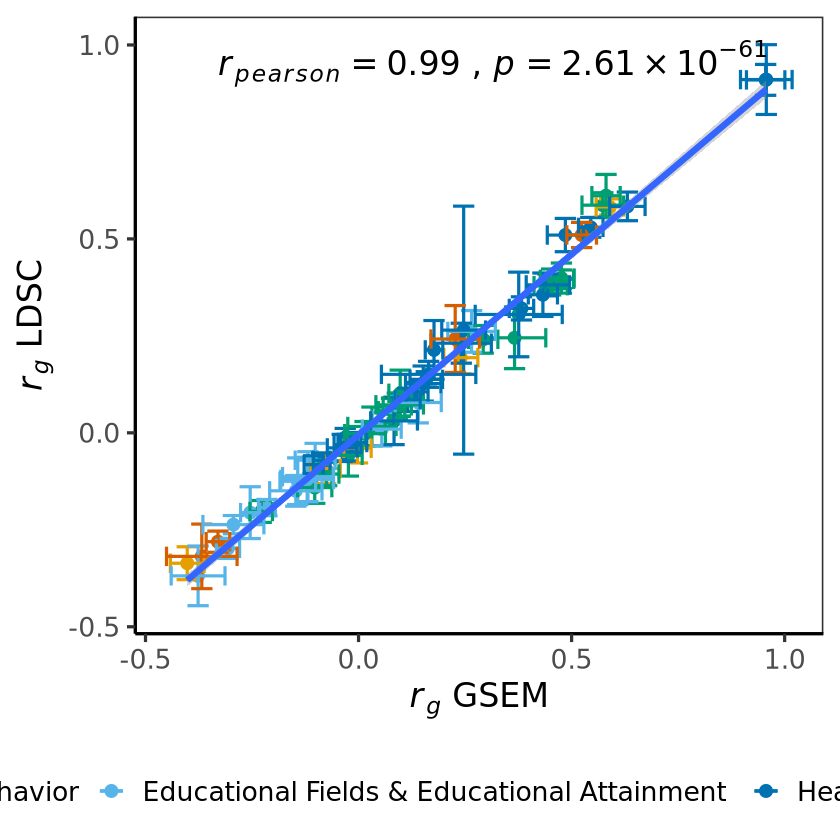

In [136]:
scatterplot_combined_ldsc_gsem <- ggplot() +
geom_point(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, color = Group, label = trait)) +
scale_color_manual(values = group_colors) +
geom_errorbar(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, color = Group, label = trait, ymin = rg_ldsc - se_ldsc, ymax = rg_ldsc + se_ldsc), width = 0.05) +
geom_errorbar(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, color = Group, label = trait, xmin = rg - se, xmax = rg + se), height = 0.05) +
annotate("text", x = Inf, y = Inf, label = deparse(pearson_labels), parse = TRUE, hjust = 1.1, vjust = 1.5) +
theme_bw(base_size = 20) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), legend.position = "bottom") +
labs(
  y = expression(italic(r[g]) ~ LDSC),
  x = expression(italic(r[g]) ~ GSEM)
) +
#geom_text_repel(combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc, color = Group, label = trait), show.legend = FALSE) +
geom_smooth(data = combined_df_gsem_ldsc, mapping = aes(x = rg, y = rg_ldsc), method = "lm", se = TRUE) 

scatterplot_combined_ldsc_gsem

In [137]:
ggsave("/local1/home/pazweifel/plots/jolien_extra_bias/ldsc_gsem_correlations_comparison.pdf", plot = scatterplot_combined_ldsc_gsem, device = pdf, width = 20, height = 15, useDingbats = FALSE)

`geom_smooth()` using formula = 'y ~ x'
`height` was translated to `width`.
